# HR Employee Attrition — Prediction Pipeline

Predicts voluntary attrition risk for each employee using XGBoost, Random Forest, and CatBoost, then selects the best-performing model and explains its predictions via SHAP and LIME.


## Behavioral Contract

The table below records invariants that have been verified as logically correct. They protect the statistical validity of the model and the fairness of the pipeline. **Do not alter these without understanding the rationale.**

| # | Invariant | Rationale |
|---|-----------|-----------|
| 1 | `Attrition_Target` is binary-encoded **before** any merge | Prevents label information from contaminating feature joins |
| 2 | Protected attrs (`Age`, `Gender`, `Marital_Status`) isolated **before** encoding | Prevents biased tree splits; retained for post-hoc fairness audits |
| 3 | Sentiment scalar: `POSITIVE → +score`, `NEGATIVE → −score` ∈ [−1, 1] | Signed scalar preserves both magnitude and direction of employee sentiment |
| 4 | Education ordinal: `HS=1, Associate=2, Bachelor=3, Master=4, PhD=5` | Preserves the known natural rank so trees can split on "Bachelor and above" |
| 5 | OHE with `drop_first=False`, `dtype=np.int8` | Tree models are immune to multicollinearity; `int8` saves 8× memory vs `int64` |
| 6 | Zero-NaN assertion enforced after encoding | Silently-introduced NaNs cause XGBoost to silently drop rows |
| 7 | All features cast to `float32` **after** encoding, **before** split | XGBoost C++ core requires float input; casting before split avoids any partial-dtype inconsistency |
| 8 | `stratify=y` on every `train_test_split` call | Preserves minority-class ratio; prevents undefined PR-AUC from an empty test class |
| 9 | Validation split carved from train **before** SMOTE | SMOTE on val/test = synthetic samples appearing in evaluation = data leakage |
| 10 | SMOTE applied **only** to `X_train_raw` | Never synthesise samples that affect evaluation |
| 11 | `scale_pos_weight = n_neg / n_pos` computed on **train split only** | Computing on full dataset leaks test-set class distribution |
| 12 | Decision threshold tuned on **val set**; all final metrics on **test set** | Prevents threshold optimism bias |
| 13 | Optuna objective = **PR-AUC** (`average_precision_score`) | ROC-AUC is overly optimistic on imbalanced data; PR-AUC penalises false positives correctly |
| 14 | Winner selection chain: ROC-AUC → PR-AUC → F1 (tie-breaker) | Multi-metric ranking prevents single-metric gaming |
| 15 | RF `class_weight="balanced_subsample"` | Recomputes weights per bootstrap sample — more stable than global `"balanced"` |
| 16 | CatBoost `auto_class_weights="Balanced"` + `use_best_model=True` | Native early stopping avoids over-fitting on minority class |
| 17 | `protected_df` split via **index alignment**, not `train_test_split` | Index-based slicing is unambiguous; avoids multi-array split edge cases across versions |


### 0. Imports & Configuration

Every notebook needs a single starting point where all tools are loaded and every setting is pinned. This cell is that starting point — nothing in the notebook executes until this cell has run successfully. It loads all required libraries, points to the raw data files, defines how outliers and warnings are handled, and sets up a consistent visual style for all plots.

**Technical note:** Centralising all imports here prevents `NameError` crashes mid-run when a downstream cell calls a function that was never imported. Optional libraries (`optuna`, `xgboost`, `catboost`, `imbalanced-learn`, `shap`, `lime`) degrade gracefully — they emit a warning and bind to `None` if not installed; downstream cells gate on `is not None` before use. Plot-theme constants (`BG`, `ACCENT`, `STAY_COLOR`, `LEAVE_COLOR`) and shared helpers (`save_fig`, `styled_title`, `print_section`) are defined once here so every EDA cell shares an identical visual identity without code duplication.

**Outputs:** All global constants, shared helper functions, and library namespaces loaded into the kernel.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS & CONFIGURATION
# All third-party imports, path config, plot theme, and shared helpers live here.
# Run this cell first; every subsequent cell depends on it.
# ═══════════════════════════════════════════════════════════════════════════════

from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any, Dict, Tuple

import joblib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from transformers import pipeline
from tqdm import tqdm

# ── Optional libraries — degrade gracefully if not installed ─────────────────
try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    optuna = None
    print("WARNING: optuna not installed — pip install optuna")

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("WARNING: xgboost not installed — pip install xgboost")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("WARNING: catboost not installed — pip install catboost")

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    SMOTE = None
    print("WARNING: imbalanced-learn not installed — pip install imbalanced-learn")

try:
    import shap
except ImportError:
    shap = None
    print("WARNING: shap not installed — pip install shap")

try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError:
    LimeTabularExplainer = None
    print("WARNING: lime not installed — pip install lime")

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Data paths (CSV files live in the data/ directory) ───────────────────────
PATH_EMPLOYEE     = "data/employee_data.csv"
PATH_COMPENSATION = "data/compensation_data.csv"
PATH_SURVEY       = "data/survey_results.csv"
PATH_ATTRITION    = "data/attrition_data.csv"
PATH_MARKET       = "data/market_benchmarks.csv"

# ── ML configuration ──────────────────────────────────────────────────────────
RANDOM_STATE    = 42
TEST_SIZE       = 0.20
VAL_SIZE        = 0.15      # fraction of train reserved for validation (pre-SMOTE)
TARGET_COL      = "Attrition_Target"
PROTECTED_COLS  = ["Age", "Gender", "Marital_Status"]

# ── Categorical encoding maps ─────────────────────────────────────────────────
# Education_Level has a universally agreed-upon rank; integer encoding preserves
# it so the model can learn "Bachelor and above" without re-discovering the order.
ORDINAL_MAPS = {
    "Education_Level": {
        "High School": 1,
        "Associate":   2,
        "Bachelor":    3,
        "Master":      4,
        "PhD":         5,
    },
}

# Department, Employment_Type, Work_Location have no natural order — OHE only.
NOMINAL_COLS = ["Department", "Employment_Type", "Work_Location"]

# ── NLP sentiment configuration ───────────────────────────────────────────────
TEXT_COL        = "Feedback_Comments"
SENTIMENT_COL   = "Feedback_Sentiment"
SENTIMENT_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"
SENTIMENT_BATCH = 32

# ── Plot theme ────────────────────────────────────────────────────────────────
BG          = "#1C1C1E"   # dark canvas background
CARD_BG     = "#2C2C2E"   # slightly lighter card / axes background
ACCENT      = "#F6C90E"   # yellow — titles and highlights
STAY_COLOR  = "#4CAF50"   # green  — employees who stayed
LEAVE_COLOR = "#EF5350"   # red    — employees who left
NEUTRAL     = "#9E9EA3"   # muted grey — secondary annotations
TEXT        = "#E5E5EA"   # primary text on dark background

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   CARD_BG,
    "axes.edgecolor":   NEUTRAL,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "grid.color":       NEUTRAL,
    "grid.alpha":       0.2,
    "legend.framealpha": 0,
})

# ── Shared helper functions ───────────────────────────────────────────────────
def save_fig(fig: plt.Figure, name: str, dpi: int = 150) -> None:
    """Save a figure to OUTPUT_DIR, display it inline, then close."""
    path = OUTPUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"  Saved → {path}")


def styled_title(ax: plt.Axes, title: str, subtitle: str = "") -> None:
    """Apply a bold title with an optional muted subtitle to an axes."""
    full = f"{title}\n{subtitle}" if subtitle else title
    ax.set_title(full, color=TEXT, fontsize=10, fontweight="bold", loc="left", pad=8)


def print_section(label: str) -> None:
    """Print a clean section separator for readable cell output."""
    print(f"\n{'─' * 60}")
    print(f"  {label}")
    print(f"{'─' * 60}")


# ── Startup confirmation ──────────────────────────────────────────────────────
print("Configuration loaded.")
print(f"  Random state     : {RANDOM_STATE}")
print(f"  Target column    : {TARGET_COL}")
print(f"  Protected cols   : {PROTECTED_COLS}")
print(f"  Ordinal cols     : {list(ORDINAL_MAPS.keys())}")
print(f"  Nominal cols     : {NOMINAL_COLS}")
print(f"  Text → sentiment : {TEXT_COL}  →  {SENTIMENT_COL}")
print(f"  Sentiment model  : {SENTIMENT_MODEL}")
print(f"  Output directory : {OUTPUT_DIR}/")


/home/kav/anaconda3/envs/athena/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration loaded.
  Random state     : 42
  Target column    : Attrition_Target
  Protected cols   : ['Age', 'Gender', 'Marital_Status']
  Ordinal cols     : ['Education_Level']
  Nominal cols     : ['Department', 'Employment_Type', 'Work_Location']
  Text → sentiment : Feedback_Comments  →  Feedback_Sentiment
  Sentiment model  : distilbert-base-uncased-finetuned-sst-2-english
  Output directory : outputs/


### 1. Load & Merge Source Data

Five separate CSV files — employee demographics, compensation details, survey responses, attrition status, and market salary benchmarks — are loaded and joined into one master table using `Employee_ID` as the shared key. Think of it like merging five separate HR spreadsheets into a single, complete employee record. Two derived values are created during the process: a binary attrition label and a pay-competitiveness ratio.

**Technical note:** `Attrition_Target` is binary-encoded *before* the merge (Behavioral Contract §1) — encoding after would allow the merge key itself to carry label information into feature columns. `Compa_Ratio` (= `Base_Salary / Benchmark_Salary`) is derived via a left join between the compensation and market-benchmark tables; the left join ensures employees without a benchmark match remain in the dataset, with `NaN` surfacing visibly at the null check rather than silently disappearing. `Employee_ID` (a row identifier with no predictive signal — would cause data leakage if kept) and `Role` (a high-cardinality text label already consumed to compute `Compa_Ratio`) are dropped post-merge.

**Inputs:** Five raw CSV files (repo root).  **Output:** `df` — 21-column merged DataFrame.


In [2]:
# ── Load all five source files ────────────────────────────────────────────────
employee     = pd.read_csv(PATH_EMPLOYEE)
compensation = pd.read_csv(PATH_COMPENSATION)
survey       = pd.read_csv(PATH_SURVEY)
attrition    = pd.read_csv(PATH_ATTRITION)
market       = pd.read_csv(PATH_MARKET)

# ── Encode target BEFORE merge (Behavioral Contract §1) ──────────────────────
# Attrition_Date has NaNs by design for stayers — only Attrition_Status is needed.
attrition[TARGET_COL] = (attrition["Attrition_Status"] == "Yes").astype(int)
attrition = attrition[["Employee_ID", TARGET_COL]]

# ── Derive Compa_Ratio: employee salary relative to market benchmark ──────────
# Left join preserves all employees; those without a benchmark get NaN (surfaced
# at the null check, not silently dropped).
comp_with_benchmark = (
    compensation
    .merge(
        employee[["Employee_ID", "Role", "Work_Location"]],
        on="Employee_ID",
    )
    .merge(
        market.rename(columns={"Location": "Work_Location"}),
        on=["Role", "Work_Location"],
        how="left",
    )
)
comp_with_benchmark["Compa_Ratio"] = (
    comp_with_benchmark["Base_Salary"] / comp_with_benchmark["Benchmark_Salary"]
)

# ── Master merge — all five tables joined on Employee_ID ─────────────────────
df = (
    employee
    .merge(
        survey[[
            "Employee_ID", "Job_Satisfaction", "Work_Life_Balance",
            "Management_Support", "Career_Development",
            "Engagement_Level", "Feedback_Comments",
        ]],
        on="Employee_ID",
    )
    .merge(
        comp_with_benchmark[[
            "Employee_ID", "Base_Salary", "Bonus",
            "Stock_Options", "Total_Compensation", "Compa_Ratio",
        ]],
        on="Employee_ID",
    )
    .merge(attrition, on="Employee_ID")
)

# ── Drop identifier and redundant columns ─────────────────────────────────────
# Employee_ID : row identifier — no predictive signal; keeping it would leak row
#               identity into features.
# Role        : high-cardinality text label already consumed to derive Compa_Ratio.
df = df.drop(columns=["Employee_ID", "Role"])


In [3]:
# ── Merge result overview ─────────────────────────────────────────────────────
print(f"Master dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

print_section("Columns Dropped During Merge")
print("  Employee_ID  — row identifier; no predictive signal; would cause data leakage.")
print("  Role         — high-cardinality text; consumed to derive Compa_Ratio; redundant post-merge.")

# ── Column inventory grouped by origin ───────────────────────────────────────
source_groups = {
    "Employee demographics" : [
        "Age", "Gender", "Marital_Status", "Department",
        "Education_Level", "Employment_Type", "Work_Location",
        "Tenure_Years", "Years_In_Role",
    ],
    "Survey responses"      : [
        "Job_Satisfaction", "Work_Life_Balance", "Management_Support",
        "Career_Development", "Engagement_Level", "Feedback_Comments",
    ],
    "Compensation + market" : [
        "Base_Salary", "Bonus", "Stock_Options", "Total_Compensation", "Compa_Ratio",
    ],
    "Derived target"        : ["Attrition_Target"],
}

print_section("Column Inventory by Source")
for source, cols in source_groups.items():
    present = [c for c in cols if c in df.columns]
    missing = [c for c in cols if c not in df.columns]
    flag = "✓" if not missing else f"⚠  missing: {missing}"
    print(f"  [{source:<26}]  {len(present)} cols  {flag}")
    for c in present:
        print(f"    · {c}")

print(f"\n  Total columns in df : {df.shape[1]}")


Master dataset shape : 10,000 rows × 20 columns

────────────────────────────────────────────────────────────
  Columns Dropped During Merge
────────────────────────────────────────────────────────────
  Employee_ID  — row identifier; no predictive signal; would cause data leakage.
  Role         — high-cardinality text; consumed to derive Compa_Ratio; redundant post-merge.

────────────────────────────────────────────────────────────
  Column Inventory by Source
────────────────────────────────────────────────────────────
  [Employee demographics     ]  8 cols  ⚠  missing: ['Years_In_Role']
    · Age
    · Gender
    · Marital_Status
    · Department
    · Education_Level
    · Employment_Type
    · Work_Location
    · Tenure_Years
  [Survey responses          ]  6 cols  ✓
    · Job_Satisfaction
    · Work_Life_Balance
    · Management_Support
    · Career_Development
    · Engagement_Level
    · Feedback_Comments
  [Compensation + market     ]  5 cols  ✓
    · Base_Salary
    · Bonus

### 1a. Post-Merge Validation — Target Distribution & Null Check

After assembling the master dataset, two quick health checks are run before any modelling can begin. First, we look at how many employees actually left versus stayed — this tells us how lopsided the prediction task is and calibrates our choice of evaluation metrics. Second, we scan every column for missing values, so that any data quality issue surfaces here immediately rather than silently corrupting a model later.

**Technical note:** The attrition rate (fraction of `Attrition_Target = 1`) directly governs the severity of class imbalance. Rates below ~20 % indicate imbalanced data where standard accuracy is a misleading metric — PR-AUC and F1 become the primary evaluation criteria (Behavioral Contract §13). The null check scans the fully-merged `df`; any NaN in a feature column at this point indicates a failed join (e.g. a `Role`/`Work_Location` combination absent from `market_benchmarks.csv`) and must be resolved before encoding.

**Inputs:** `df` (merged).  **Output:** Printed distribution summary; any NaN columns surfaced by name.


In [4]:
# ── Target distribution ───────────────────────────────────────────────────────
print_section("Target Distribution")
counts = df[TARGET_COL].value_counts()
print(f"  Stayed (0) : {counts.get(0, 0):,}")
print(f"  Left   (1) : {counts.get(1, 0):,}")
print(f"  Attrition rate : {df[TARGET_COL].mean():.2%}")

# ── Null check ────────────────────────────────────────────────────────────────
print_section("Null Check")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
if nulls.empty:
    print("  ✓  No nulls detected across all columns.")
else:
    print("  ⚠  Nulls found — resolve before encoding:")
    for col, n in nulls.items():
        print(f"    · {col:<25} {n:>6,} missing")



────────────────────────────────────────────────────────────
  Target Distribution
────────────────────────────────────────────────────────────
  Stayed (0) : 8,192
  Left   (1) : 1,808
  Attrition rate : 18.08%

────────────────────────────────────────────────────────────
  Null Check
────────────────────────────────────────────────────────────
  ✓  No nulls detected across all columns.


### 2. Isolate Protected Attributes

Some employee attributes — age, gender, and marital status — are legally and ethically sensitive. We deliberately remove them from the feature set that the model will train on, so it cannot build discrimination into its predictions. These columns are not discarded; they are stored separately so that after training we can audit whether the model's error rates are equal across demographic groups.

**Technical note:** XGBoost is a greedy ensemble of CART trees. At each split node it evaluates every candidate feature using the gain formula:

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

where $G$ is the sum of first-order loss gradients and $H$ the sum of second-order (Hessian) terms. If `Gender` or `Age` correlates with attrition — even spuriously, due to historical HR patterns in the data — the gain will be non-zero and the feature **will** be selected. This encodes demographic bias directly into tree weights. Removing these columns before fitting prevents selection entirely. `protected_df` is retained in memory for post-hoc fairness audits such as equalised false-positive rates across gender groups (Behavioral Contract §2).

**Inputs:** `df`.  **Outputs:** `model_df` (features for training), `protected_df` (demographic attributes, audit-only).


In [5]:
# ── Validate that all declared protected columns are present ──────────────────
missing_protected = [c for c in PROTECTED_COLS if c not in df.columns]
if missing_protected:
    raise ValueError(f"Protected columns not found in df: {missing_protected}")

# ── Separate protected attributes from modelling features ─────────────────────
protected_df = df[PROTECTED_COLS].copy()
model_df     = df.drop(columns=PROTECTED_COLS).copy()

# ── Confirmation ──────────────────────────────────────────────────────────────
print_section("Protected Attribute Isolation")
print(f"  Isolated   : {PROTECTED_COLS}  → stored in protected_df")
print(f"  model_df   : {model_df.shape[1]} columns  {list(model_df.columns)}")



────────────────────────────────────────────────────────────
  Protected Attribute Isolation
────────────────────────────────────────────────────────────
  Isolated   : ['Age', 'Gender', 'Marital_Status']  → stored in protected_df
  model_df   : 17 columns  ['Department', 'Tenure_Years', 'Employment_Type', 'Education_Level', 'Work_Location', 'Job_Satisfaction', 'Work_Life_Balance', 'Management_Support', 'Career_Development', 'Engagement_Level', 'Feedback_Comments', 'Base_Salary', 'Bonus', 'Stock_Options', 'Total_Compensation', 'Compa_Ratio', 'Attrition_Target']


### 3. NLP Sentiment Extraction

Every employee in the dataset left a short free-text comment in a survey. A machine learning model cannot read words directly — it needs numbers. This cell uses a pre-trained language model to read each comment and produce a single score between −1 (very negative) and +1 (very positive), which can then be used as a regular numeric feature. The raw comment column is dropped afterwards; all the information it contained is now captured by the score.

**Technical note:** The pipeline uses `distilbert-base-uncased-finetuned-sst-2-english` — a DistilBERT model fine-tuned on the Stanford Sentiment Treebank (SST-2). The model returns a `label` (`POSITIVE` / `NEGATIVE`) and a soft `score` (sigmoid confidence ∈ (0, 1)). The `score_to_signed` function applies the transformation: `+score` if `POSITIVE`, `−score` if `NEGATIVE`, producing a single continuous scalar on [−1, 1] that encodes both direction and certainty (Behavioral Contract §3). Empty or NaN comments are replaced with the neutral placeholder `"no comment provided"` before inference to avoid tokeniser errors. Inference is batched at `SENTIMENT_BATCH=32` for throughput.

**Inputs:** `model_df` with `Feedback_Comments`.  **Output:** `model_df` with `Feedback_Sentiment` (float), `Feedback_Comments` dropped.


In [6]:
# ── Load sentiment pipeline ───────────────────────────────────────────────────
print(f"Loading model : {SENTIMENT_MODEL}")
sentiment_pipe = pipeline(
    task       = "sentiment-analysis",
    model      = SENTIMENT_MODEL,
    truncation = True,
    max_length = 512,
    device     = -1,          # CPU; set to 0 for GPU
    batch_size = SENTIMENT_BATCH,
)

def score_to_signed(result: dict) -> float:
    """Map HuggingFace output → signed scalar ∈ [−1, 1] (Behavioral Contract §3)."""
    s = result["score"]
    return s if result["label"] == "POSITIVE" else -s

# ── Pre-inference audit ───────────────────────────────────────────────────────
texts_raw  = model_df[TEXT_COL].fillna("").str.strip()
n_total    = len(texts_raw)
n_empty    = (texts_raw == "").sum()
texts_safe = [t if t else "no comment provided" for t in texts_raw.tolist()]

print_section(f"Text Audit — {TEXT_COL}")
print(f"  Total records   : {n_total:,}")
print(f"  Empty / NaN     : {n_empty}" + ("  — replaced with neutral placeholder" if n_empty else "  — none"))
print(f"  Unique comments : {texts_raw.nunique()}")
print(f"  Sample texts    :")
for t in texts_raw.dropna().unique()[:3]:
    print(f"    · {t[:80]}")

# ── Batch inference ───────────────────────────────────────────────────────────
print(f"\n  Running inference   : {n_total:,} records  (batch_size={SENTIMENT_BATCH})")
raw_results = []
for i in tqdm(range(0, len(texts_safe), SENTIMENT_BATCH), desc="Sentiment batches"):
    raw_results.extend(sentiment_pipe(texts_safe[i : i + SENTIMENT_BATCH]))

model_df[SENTIMENT_COL] = [score_to_signed(r) for r in raw_results]

# ── Post-inference audit ──────────────────────────────────────────────────────
scores     = model_df[SENTIMENT_COL]
n_pos_sent = (scores > 0).sum()
n_neg_sent = (scores < 0).sum()

print_section(f"Sentiment Results → '{SENTIMENT_COL}'")
print(f"  Range    : [{scores.min():.4f},  {scores.max():.4f}]")
print(f"  Mean     : {scores.mean():.4f}   Median : {scores.median():.4f}")
print(f"  Positive : {n_pos_sent:,}  ({n_pos_sent / n_total:.1%})")
print(f"  Negative : {n_neg_sent:,}  ({n_neg_sent / n_total:.1%})")

# ── Drop raw text column; signal now captured by sentiment score ──────────────
model_df = model_df.drop(columns=[TEXT_COL])
print(f"\n  '{TEXT_COL}' dropped  →  model_df shape: {model_df.shape}")


Loading model : distilbert-base-uncased-finetuned-sst-2-english


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 829.05it/s]



────────────────────────────────────────────────────────────
  Text Audit — Feedback_Comments
────────────────────────────────────────────────────────────
  Total records   : 10,000
  Empty / NaN     : 0  — none
  Unique comments : 25
  Sample texts    :
    · Salary is decent but bonuses could be better.
    · Work is okay but growth opportunities are limited.
    · Very happy with my role, learning a lot every day.

  Running inference   : 10,000 records  (batch_size=32)


Sentiment batches: 100%|██████████| 313/313 [00:47<00:00,  6.57it/s]


────────────────────────────────────────────────────────────
  Sentiment Results → 'Feedback_Sentiment'
────────────────────────────────────────────────────────────
  Range    : [-0.9998,  0.9999]
  Mean     : 0.6660   Median : 0.9993
  Positive : 8,385  (83.9%)
  Negative : 1,615  (16.2%)

  'Feedback_Comments' dropped  →  model_df shape: (10000, 17)


### 4. Categorical Encoding

Machine learning models require every input to be a number. Three columns in the dataset are categories (text labels), so they need to be converted. This cell handles that conversion in two passes. First, `Education_Level` is mapped to an integer rank because there is a natural order (a PhD is higher than a Bachelor's degree). Second, `Department`, `Employment_Type`, and `Work_Location` are exploded into binary (0/1) indicator columns because those categories have no meaningful ordering.

**Technical note — why two different strategies:**

- **Ordinal encoding** (`Education_Level`): The five education levels have a universally agreed rank (HS < Associate < Bachelor < Master < PhD). Preserving this as integers 1–5 lets the model learn a single threshold split such as "Education_Level ≥ 3 → lower risk", rather than independently discovering the relationship from five separate binary columns (Behavioral Contract §4).

- **One-hot encoding (OHE)** (`Department`, `Employment_Type`, `Work_Location`): These have no natural rank. Assigning integers — e.g. Finance=0, HR=1, IT=2 — would imply `IT > HR > Finance`, a spurious ordinal relationship the model would exploit. OHE creates one binary column per category, making all categories mathematically independent. `drop_first=False` retains all dummies because XGBoost evaluates one feature per split — it has no design matrix and is immune to perfect multicollinearity. `dtype=np.int8` stores each binary column in 1 byte instead of 8, an 8× memory reduction at zero precision cost (Behavioral Contract §5).

- A **hard assertion** after encoding confirms zero NaN values were introduced (Behavioral Contract §6).

**Inputs:** `model_df` with categorical columns.  **Output:** `model_df` with all columns numeric, ready for train/test split.


In [7]:
cols_before_encoding = list(model_df.columns)

# ── 4.1  Ordinal Encoding — Education_Level ───────────────────────────────────
# Unseen-value guard: every category in the data must have a mapping entry.
# A missing key would silently produce NaN, corrupting all downstream steps.
print_section("4.1  Ordinal Encoding")
for col, mapping in ORDINAL_MAPS.items():
    if col not in model_df.columns:
        print(f"  WARNING: '{col}' not found — skipping.")
        continue

    original_values = sorted(model_df[col].dropna().unique().tolist())
    unseen = set(original_values) - set(mapping.keys())
    if unseen:
        raise ValueError(
            f"'{col}' contains values absent from ORDINAL_MAPS: {unseen}\n"
            "Add them to ORDINAL_MAPS before continuing."
        )

    model_df[col] = model_df[col].map(mapping)
    encoded_values = sorted(model_df[col].dropna().unique().tolist())
    print(f"  {col}")
    print(f"    Before  : {original_values}")
    print(f"    After   : {encoded_values}")

# ── 4.2  One-Hot Encoding — Department, Employment_Type, Work_Location ────────
# drop_first=False: XGBoost is tree-based; multicollinearity is irrelevant.
# dtype=np.int8: binary columns need 1 byte, not 8 — 8× memory saving.
print_section("4.2  One-Hot Encoding")
existing_nominal = [c for c in NOMINAL_COLS if c in model_df.columns]
missing_nominal  = [c for c in NOMINAL_COLS if c not in model_df.columns]

if missing_nominal:
    print(f"  WARNING: Not found, skipping: {missing_nominal}")

for col in existing_nominal:
    cats = sorted(model_df[col].dropna().unique().tolist())
    print(f"  {col:<22}  {len(cats)} categories  →  {len(cats)} binary columns")

model_df = pd.get_dummies(
    model_df,
    columns    = existing_nominal,
    drop_first = False,
    dtype      = np.int8,
)

# ── Encoding summary ──────────────────────────────────────────────────────────
cols_after_encoding  = list(model_df.columns)
new_dummy_cols       = [c for c in cols_after_encoding if c not in cols_before_encoding]
removed_nominal_cols = [c for c in cols_before_encoding if c not in cols_after_encoding]

print_section("Encoding Summary")
print(f"  Columns before encoding   : {len(cols_before_encoding)}")
print(f"  Originals removed (OHE)   : −{len(removed_nominal_cols)}  {removed_nominal_cols}")
print(f"  Dummy columns added (OHE) : +{len(new_dummy_cols)}")
print(f"  Net change                : +{len(new_dummy_cols) - len(removed_nominal_cols)}")
print(f"  Columns after encoding    : {len(cols_after_encoding)}")
print(f"\n  New dummy columns:")
for c in new_dummy_cols:
    print(f"    · {c}")

# ── Sanity checks (Behavioral Contract §5, §6) ────────────────────────────────
assert TARGET_COL in model_df.columns,         f"Target column '{TARGET_COL}' missing!"
assert model_df.isnull().sum().sum() == 0,     "NaNs detected after encoding — check ORDINAL_MAPS."

print(f"\n  ✓  Target '{TARGET_COL}' present")
print(f"  ✓  Zero NaNs after encoding")
print(f"  ✓  model_df shape: {model_df.shape}  →  ready for train/test split")



────────────────────────────────────────────────────────────
  4.1  Ordinal Encoding
────────────────────────────────────────────────────────────
  Education_Level
    Before  : ['Associate', 'Bachelor', 'High School', 'Master', 'PhD']
    After   : [1, 2, 3, 4, 5]

────────────────────────────────────────────────────────────
  4.2  One-Hot Encoding
────────────────────────────────────────────────────────────
  Department              8 categories  →  8 binary columns
  Employment_Type         3 categories  →  3 binary columns
  Work_Location           9 categories  →  9 binary columns

────────────────────────────────────────────────────────────
  Encoding Summary
────────────────────────────────────────────────────────────
  Columns before encoding   : 17
  Originals removed (OHE)   : −3  ['Department', 'Employment_Type', 'Work_Location']
  Dummy columns added (OHE) : +20
  Net change                : +17
  Columns after encoding    : 34

  New dummy columns:
    · Department_Custom

### 5. Exploratory Data Analysis

Before building any model, we examine the data visually to understand its shape, spot patterns, and identify where the highest-risk employees cluster. This section produces seven plots covering class balance, tenure trends, compensation signals, demographic sub-populations, feature correlations, and the intersection of multiple risk factors. Each plot answers one focused business question.

**Technical note:** All plots operate on `model_df` — the fully encoded, post-protected-attribute-isolation dataset — which means OHE dummy columns are available for the categorical charts and `Education_Level` is already its integer rank. A short variable alias `df = model_df` is used internally to keep plot code readable. Temporary helper columns (e.g. `_dept`, `_loc`, `_cr_bin`) are always dropped inline after use to avoid polluting `df` for the next plot.


#### 5a. Workforce Attrition Overview

This plot gives the first big-picture view of the dataset. It answers three questions at once: what fraction of employees left (the donut), whether there is a monthly exit spike (the bar chart), and which departments are out-performing or under-performing the company average on retention (the horizontal bar). Red bars indicate departments with above-average attrition; green bars indicate below-average.

**Technical note:** The donut chart is a pie chart with `width=0.55` to hollow the centre; the attrition rate is placed at the centroid `(0, 0)`. Department attrition rates are computed as the conditional mean of the binary target across the OHE dummy columns (`Department_*`). The dashed vertical line marks the global average, giving an instant above/below reference for each bar.

**Business question:** How severe is the class imbalance? Which departments need immediate retention intervention?


Dataset : 10,000 employees  |  1,808 left (18.1%)  |  8,192 stayed


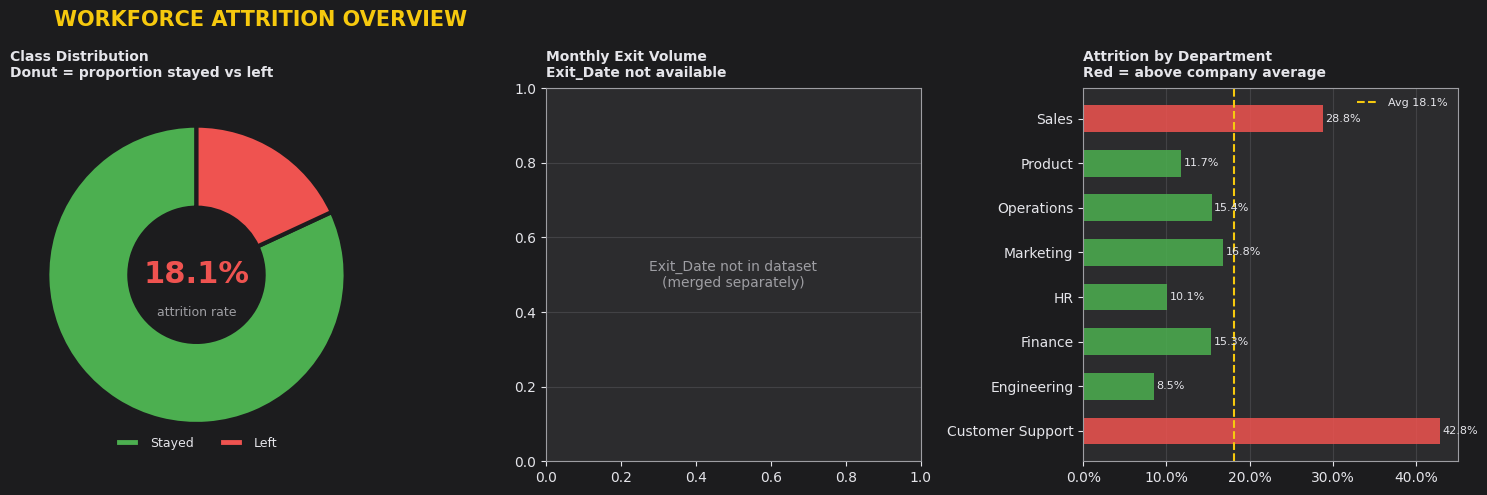

  Saved → outputs/01_overview.png


In [8]:
# ── Alias for EDA readability ─────────────────────────────────────────────────
# model_df is the encoded dataset; df is a local alias used throughout EDA cells.
df     = model_df.copy()
TARGET = TARGET_COL

attrition_rate = df[TARGET].mean()
n_total        = len(df)
n_left         = int(df[TARGET].sum())
n_stay         = n_total - n_left

print(f"Dataset : {n_total:,} employees  |  {n_left:,} left ({attrition_rate:.1%})  |  {n_stay:,} stayed")

# ── Plot 1 — Class balance overview ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)
fig.suptitle("WORKFORCE ATTRITION OVERVIEW", color=ACCENT,
             fontsize=15, fontweight="bold", x=0.04, ha="left")

# Donut — proportion stayed vs left
ax = axes[0]
wedges, _ = ax.pie(
    [n_stay, n_left], colors=[STAY_COLOR, LEAVE_COLOR],
    startangle=90, wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=3),
)
ax.text(0, 0, f"{attrition_rate:.1%}", ha="center", va="center",
        fontsize=22, fontweight="bold", color=LEAVE_COLOR)
ax.text(0, -0.25, "attrition rate", ha="center", va="center",
        fontsize=9, color=NEUTRAL)
styled_title(ax, "Class Distribution", "Donut = proportion stayed vs left")
ax.legend(["Stayed", "Left"], loc="lower center", ncol=2,
          facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=9)

# Monthly exit volume (only if Exit_Date column present)
ax = axes[1]
if "Exit_Date" in df.columns:
    exits = (pd.to_datetime(df.loc[df[TARGET] == 1, "Exit_Date"])
               .dt.to_period("M").value_counts().sort_index())
    ax.bar(range(len(exits)), exits.values, color=LEAVE_COLOR, alpha=0.8, width=0.7)
    step = max(1, len(exits) // 6)
    ax.set_xticks(range(0, len(exits), step))
    ax.set_xticklabels([str(exits.index[i]) for i in range(0, len(exits), step)],
                       rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Exits")
    styled_title(ax, "Monthly Exit Volume", "When are people leaving?")
else:
    ax.text(0.5, 0.5, "Exit_Date not in dataset\n(merged separately)",
            ha="center", va="center", transform=ax.transAxes, color=NEUTRAL, fontsize=10)
    styled_title(ax, "Monthly Exit Volume", "Exit_Date not available")
ax.yaxis.grid(True)
ax.set_axisbelow(True)

# Attrition rate by department
ax = axes[2]
dept_cols = [c for c in df.columns if c.startswith("Department_")]
if dept_cols:
    dept_rates = {
        col.replace("Department_", ""): df.loc[df[col] == 1, TARGET].mean()
        for col in dept_cols if (df[col] == 1).sum() > 10
    }
    if dept_rates:
        names  = list(dept_rates.keys())
        rates  = list(dept_rates.values())
        colors = [LEAVE_COLOR if r > attrition_rate else STAY_COLOR for r in rates]
        bars   = ax.barh(names, rates, color=colors, alpha=0.85, height=0.6)
        ax.axvline(attrition_rate, color=ACCENT, lw=1.5, ls="--",
                   label=f"Avg {attrition_rate:.1%}")
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        for bar, r in zip(bars, rates):
            ax.text(r + 0.003, bar.get_y() + bar.get_height() / 2,
                    f"{r:.1%}", va="center", fontsize=8)
        ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
        styled_title(ax, "Attrition by Department", "Red = above company average")
ax.xaxis.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, "01_overview")


#### 5b. Tenure Risk Window

This plot shows the distribution of years of service for employees who stayed vs those who left — overlaid as density histograms with smooth KDE curves and median marker lines. It answers the question: at which point in an employee's career is the risk of leaving highest?

**Technical note:** Density normalisation (`density=True`) is used so that the two histograms are directly comparable despite possibly different class counts. The KDE is `scipy.stats.gaussian_kde` with default bandwidth (Scott's rule: $h = n^{-1/5} \sigma$). Statistical significance is assessed with the Mann-Whitney U test (non-parametric; no normality assumption required), reporting the p-value on the subtitle. A p-value < 0.05 confirms that the tenure distributions of leavers and stayers are genuinely different, not a sampling artefact.

**Business question:** At what tenure band is churn risk highest — and should retention programmes target new hires or mid-career employees?


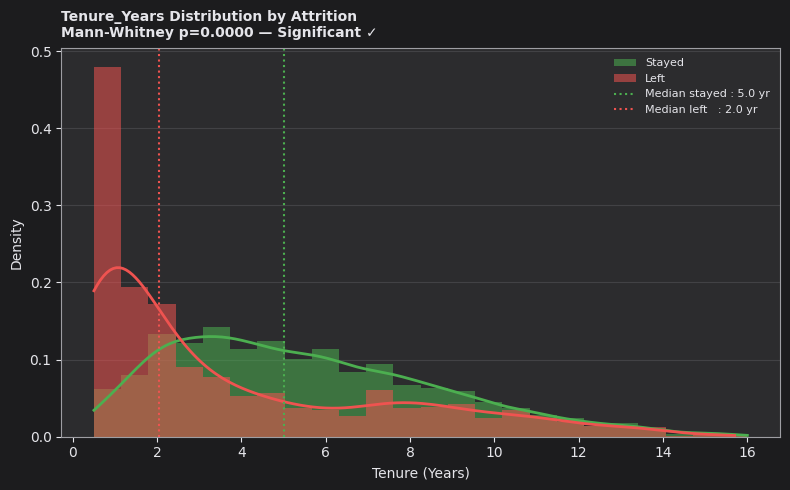

  Saved → outputs/02_tenure_risk.png


In [9]:
# ── Plot 2 — Tenure risk window ───────────────────────────────────────────────
col    = "Tenure_Years"
stayed = df.loc[df[TARGET] == 0, col].dropna()
left   = df.loc[df[TARGET] == 1, col].dropna()
bins   = np.linspace(df[col].min(), df[col].max(), 25)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)

ax.hist(stayed, bins=bins, color=STAY_COLOR, alpha=0.55, label="Stayed", density=True)
ax.hist(left,   bins=bins, color=LEAVE_COLOR, alpha=0.55, label="Left",   density=True)

for data, color in [(stayed, STAY_COLOR), (left, LEAVE_COLOR)]:
    kde = stats.gaussian_kde(data)
    x   = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, kde(x), color=color, lw=2)

ax.axvline(stayed.median(), color=STAY_COLOR, ls=":", lw=1.5,
           label=f"Median stayed : {stayed.median():.1f} yr")
ax.axvline(left.median(),   color=LEAVE_COLOR, ls=":", lw=1.5,
           label=f"Median left   : {left.median():.1f} yr")

_, pval = stats.mannwhitneyu(stayed, left, alternative="two-sided")
styled_title(ax, f"{col} Distribution by Attrition",
             f"Mann-Whitney p={pval:.4f} — {'Significant ✓' if pval < 0.05 else 'Not significant'}")

ax.set(xlabel="Tenure (Years)", ylabel="Density")
ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
save_fig(fig, "02_tenure_risk")


#### 5c. Compensation Risk Signals

Pay is one of the most cited reasons for leaving. This three-panel plot investigates it from multiple angles: a violin plot comparing the pay-competitiveness ratio (`Compa_Ratio = Base_Salary / Benchmark_Salary`) between leavers and stayers, a binned bar chart showing how attrition rate steps up as pay falls below market, and a scatter plot of base salary vs bonus coloured by outcome.

**Technical note:** `Compa_Ratio` < 1.0 means the employee is paid below the market benchmark; the dashed line at `y=1.0` marks market parity. The violin plot shows the full distribution shape alongside the median (yellow line). The binned bar chart uses `pd.cut` with 10 equal-width bins; bins with fewer than 5 records are excluded to prevent noisy point estimates. A Mann-Whitney U p-value is shown on the violin subtitle. The temporary `_cr_bin` column is dropped inline after use.

**Business question:** Are underpaid employees meaningfully more likely to leave — and at what pay threshold does attrition risk jump sharply?


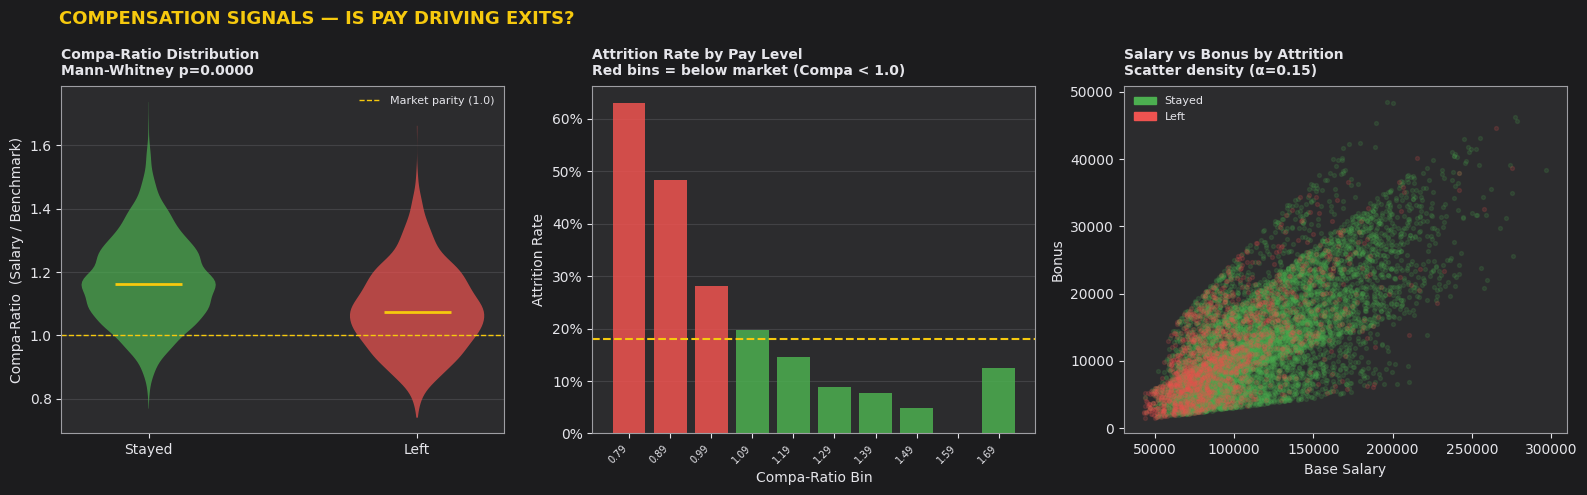

  Saved → outputs/03_compensation_risk.png


In [10]:
# ── Plot 3 — Compensation risk signals ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.suptitle("COMPENSATION SIGNALS — IS PAY DRIVING EXITS?",
             color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

# Violin — Compa-Ratio by attrition
ax = axes[0]
if "Compa_Ratio" in df.columns:
    data_plot = [df.loc[df[TARGET] == 0, "Compa_Ratio"].dropna(),
                 df.loc[df[TARGET] == 1, "Compa_Ratio"].dropna()]
    parts = ax.violinplot(data_plot, positions=[0, 1], showmedians=True, showextrema=False)
    for pc, c in zip(parts["bodies"], [STAY_COLOR, LEAVE_COLOR]):
        pc.set_facecolor(c)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color(ACCENT)
    parts["cmedians"].set_linewidth(2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Stayed", "Left"])
    ax.axhline(1.0, color=ACCENT, ls="--", lw=1, label="Market parity (1.0)")
    ax.set_ylabel("Compa-Ratio  (Salary / Benchmark)")
    ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
    _, pval = stats.mannwhitneyu(*data_plot, alternative="two-sided")
    styled_title(ax, "Compa-Ratio Distribution", f"Mann-Whitney p={pval:.4f}")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

# Binned attrition rate vs Compa-Ratio
ax = axes[1]
if "Compa_Ratio" in df.columns:
    df["_cr_bin"] = pd.cut(df["Compa_Ratio"], bins=10)
    cr_agg = df.groupby("_cr_bin", observed=True)[TARGET].agg(["mean", "count"]).reset_index()
    cr_agg = cr_agg[cr_agg["count"] > 5]
    midpoints  = [iv.mid for iv in cr_agg["_cr_bin"]]
    bar_colors = [LEAVE_COLOR if m < 1.0 else STAY_COLOR for m in midpoints]
    ax.bar(range(len(cr_agg)), cr_agg["mean"], color=bar_colors, alpha=0.85)
    ax.axhline(attrition_rate, color=ACCENT, ls="--", lw=1.5)
    ax.set_xticks(range(len(cr_agg)))
    ax.set_xticklabels([f"{m:.2f}" for m in midpoints], rotation=45, ha="right", fontsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel("Compa-Ratio Bin")
    ax.set_ylabel("Attrition Rate")
    styled_title(ax, "Attrition Rate by Pay Level", "Red bins = below market (Compa < 1.0)")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    df.drop(columns=["_cr_bin"], inplace=True)

# Salary vs Bonus scatter coloured by attrition
ax = axes[2]
bonus_col = next((c for c in ["Bonus_Pct", "Bonus", "Bonus_Amount"] if c in df.columns), None)
if bonus_col and "Base_Salary" in df.columns:
    for label, color in [(0, STAY_COLOR), (1, LEAVE_COLOR)]:
        subset = df[df[TARGET] == label]
        ax.scatter(subset["Base_Salary"], subset[bonus_col],
                   c=color, alpha=0.15, s=8, rasterized=True)
    patches = [mpatches.Patch(color=STAY_COLOR, label="Stayed"),
               mpatches.Patch(color=LEAVE_COLOR, label="Left")]
    ax.legend(handles=patches, facecolor=CARD_BG, edgecolor="none",
              labelcolor=TEXT, fontsize=8)
    ax.set_xlabel("Base Salary")
    ax.set_ylabel(bonus_col)
    styled_title(ax, "Salary vs Bonus by Attrition", "Scatter density (α=0.15)")
else:
    ax.text(0.5, 0.5, "Bonus column not found", ha="center", va="center",
            transform=ax.transAxes, color=NEUTRAL, fontsize=10)

plt.tight_layout()
save_fig(fig, "03_compensation_risk")


#### 5d. Sub-Population Risk Heatmaps

Not all groups within the company face the same attrition risk. This plot cross-tabulates attrition rates across two pairs of dimensions: department × education level, and department × work location. Cells shaded red indicate sub-populations with above-average risk; cells shaded blue indicate below-average risk. These are the most actionable findings for targeted retention programmes.

**Technical note:** The OHE dummy columns (`Department_*`, `Work_Location_*`) are reconstructed back into a single categorical column via `pd.from_dummies` before pivoting — this is purely for readability of the heatmap axis labels. `pd.pivot_table(aggfunc="mean")` computes the attrition rate (mean of a binary label) per cell. The diverging colormap `RdBu_r` is centred on the dataset-level `attrition_rate` so blue/red carry a consistent meaning across both heatmaps. Temporary columns `_dept` and `_loc` are dropped inline.

**Business question:** Which specific department-location or department-education combinations account for the highest attrition — and where should retention resources be concentrated?


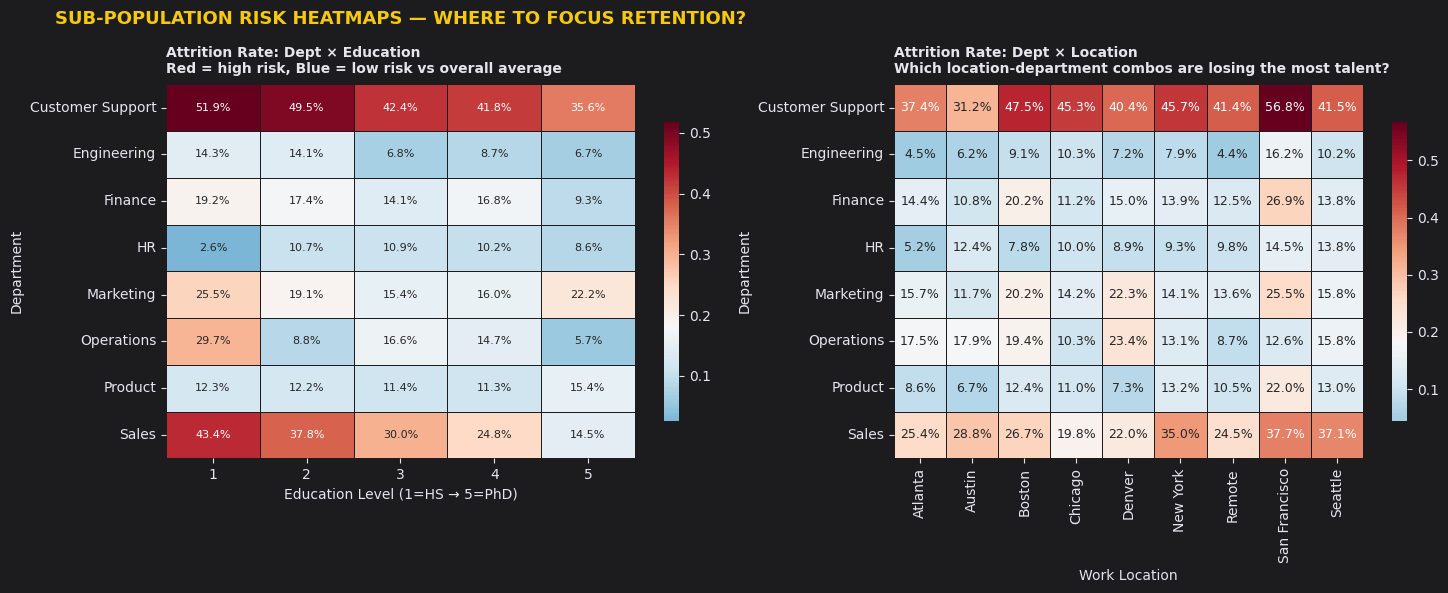

  Saved → outputs/04_subpopulation_heatmaps.png


In [11]:
# ── Plot 4 — Sub-population risk heatmaps ────────────────────────────────────
dept_cols = [c for c in df.columns if c.startswith("Department_")]
loc_cols  = [c for c in df.columns if c.startswith("Work_Location_")]

if not (dept_cols and "Education_Level" in df.columns):
    print("Skipping heatmaps — Department_ or Education_Level columns not found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)
    fig.suptitle("SUB-POPULATION RISK HEATMAPS — WHERE TO FOCUS RETENTION?",
                 color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

    dept_names = [c.replace("Department_", "") for c in dept_cols]
    df["_dept"] = pd.from_dummies(
        df[dept_cols].rename(columns=dict(zip(dept_cols, dept_names)))
    )

    # Dept × Education
    ax = axes[0]
    heat1 = df.pivot_table(values=TARGET, index="_dept",
                           columns="Education_Level", aggfunc="mean")
    sns.heatmap(heat1, ax=ax, cmap="RdBu_r", center=attrition_rate,
                annot=True, fmt=".1%", linewidths=0.5, linecolor=BG,
                annot_kws={"size": 8}, cbar_kws={"shrink": 0.8})
    ax.set_xlabel("Education Level (1=HS → 5=PhD)")
    ax.set_ylabel("Department")
    styled_title(ax, "Attrition Rate: Dept × Education",
                 "Red = high risk, Blue = low risk vs overall average")

    # Dept × Work Location
    ax = axes[1]
    if loc_cols:
        loc_names = [c.replace("Work_Location_", "") for c in loc_cols]
        df["_loc"] = pd.from_dummies(
            df[loc_cols].rename(columns=dict(zip(loc_cols, loc_names)))
        )
        heat2 = df.pivot_table(values=TARGET, index="_dept",
                               columns="_loc", aggfunc="mean")
        sns.heatmap(heat2, ax=ax, cmap="RdBu_r", center=attrition_rate,
                    annot=True, fmt=".1%", linewidths=0.5, linecolor=BG,
                    annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
        ax.set_xlabel("Work Location")
        ax.set_ylabel("Department")
        styled_title(ax, "Attrition Rate: Dept × Location",
                     "Which location-department combos are losing the most talent?")
        df.drop(columns=["_loc"], inplace=True, errors="ignore")
    else:
        ax.text(0.5, 0.5, "Work_Location_ columns not found",
                ha="center", va="center", transform=ax.transAxes, color=NEUTRAL)

    df.drop(columns=["_dept"], inplace=True, errors="ignore")

    plt.tight_layout()
    save_fig(fig, "04_subpopulation_heatmaps")


#### 5e. Feature Correlation Matrix

This heatmap shows how strongly each numeric feature is linearly correlated with every other, focussed on the 14 features most correlated with the attrition target. It serves two purposes: identifying which individual features carry the most predictive signal, and checking for pairs of features that are so strongly correlated with each other that they carry redundant information.

**Technical note:** Only the lower triangle of the correlation matrix is rendered (`np.triu` mask) to avoid visual redundancy. Features are ranked by `|Pearson r|` with `Attrition_Target` — the 14 highest-ranked features are selected. The target column column is highlighted with a yellow rectangle. Note that Pearson r measures *linear* correlation only; tree-based models capture non-linear relationships that this matrix will underestimate. Multicollinearity between features is not a problem for XGBoost or Random Forest (unlike linear models), but it is useful information for feature selection and engineering.

**Business question:** Which raw features are the most individually predictive? Are any two features measuring the same thing (and thus redundant)?


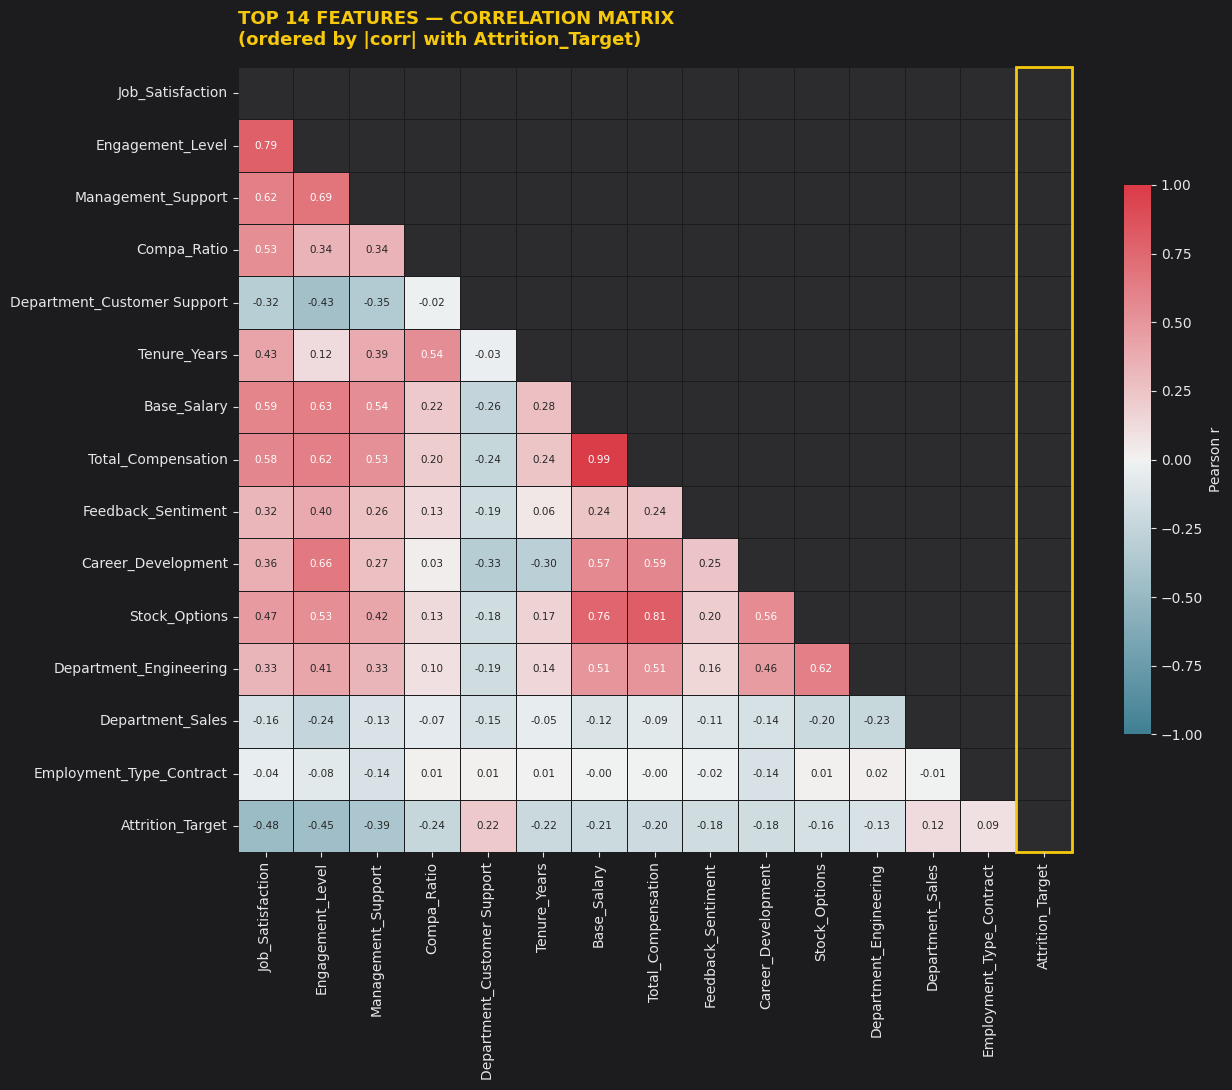

  Saved → outputs/05_correlation_matrix.png


In [12]:
# ── Plot 5 — Feature correlation matrix (top-14 by |corr| with target) ───────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_with_target = (
    df[num_cols].corr()[TARGET].drop(TARGET)
    .abs().sort_values(ascending=False)
)
top_feats   = corr_with_target.head(14).index.tolist() + [TARGET]
corr_matrix = df[top_feats].corr()

fig, ax = plt.subplots(figsize=(13, 11), facecolor=BG)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap=cmap, center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            linewidths=0.4, linecolor=BG,
            annot_kws={"size": 7.5},
            cbar_kws={"shrink": 0.7, "label": "Pearson r"})
ax.set_title(
    "TOP 14 FEATURES — CORRELATION MATRIX\n(ordered by |corr| with Attrition_Target)",
    color=ACCENT, fontsize=13, fontweight="bold", loc="left", pad=16,
)
# Highlight the target column
for i, label in enumerate(corr_matrix.columns):
    if label == TARGET:
        ax.add_patch(plt.Rectangle((i, 0), 1, len(corr_matrix),
                                   fill=False, edgecolor=ACCENT, lw=2, clip_on=False))

plt.tight_layout()
save_fig(fig, "05_correlation_matrix")


#### 5f. Categorical Attrition Rates (Chi² Ranked)

This three-panel chart shows the attrition rate for each category within the three nominal features: employment type, work location, and department. Bars are coloured red when the category's attrition rate exceeds the company average, and green when it falls below. Each panel carries a Chi-squared test p-value indicating whether the attrition rate difference across categories for that feature is statistically significant or could be due to chance.

**Technical note:** Because the categorical features were OHE-encoded into dummy columns, the original category is reconstructed per record by calling `.idxmax(axis=1)` on the dummy block — this identifies which dummy column is 1 for each row, recovering the original label. `scipy.stats.chi2_contingency` is applied to a 2D contingency table (categories × attrition outcome). Significance stars follow the standard convention: `***` p < 0.001, `**` p < 0.01, `*` p < 0.05, `ns` not significant. Group size `n` is annotated above each bar to contextualise small-sample rate estimates.

**Business question:** Which employment arrangement, work location, or department is statistically associated with attrition — or is the apparent variation just noise?


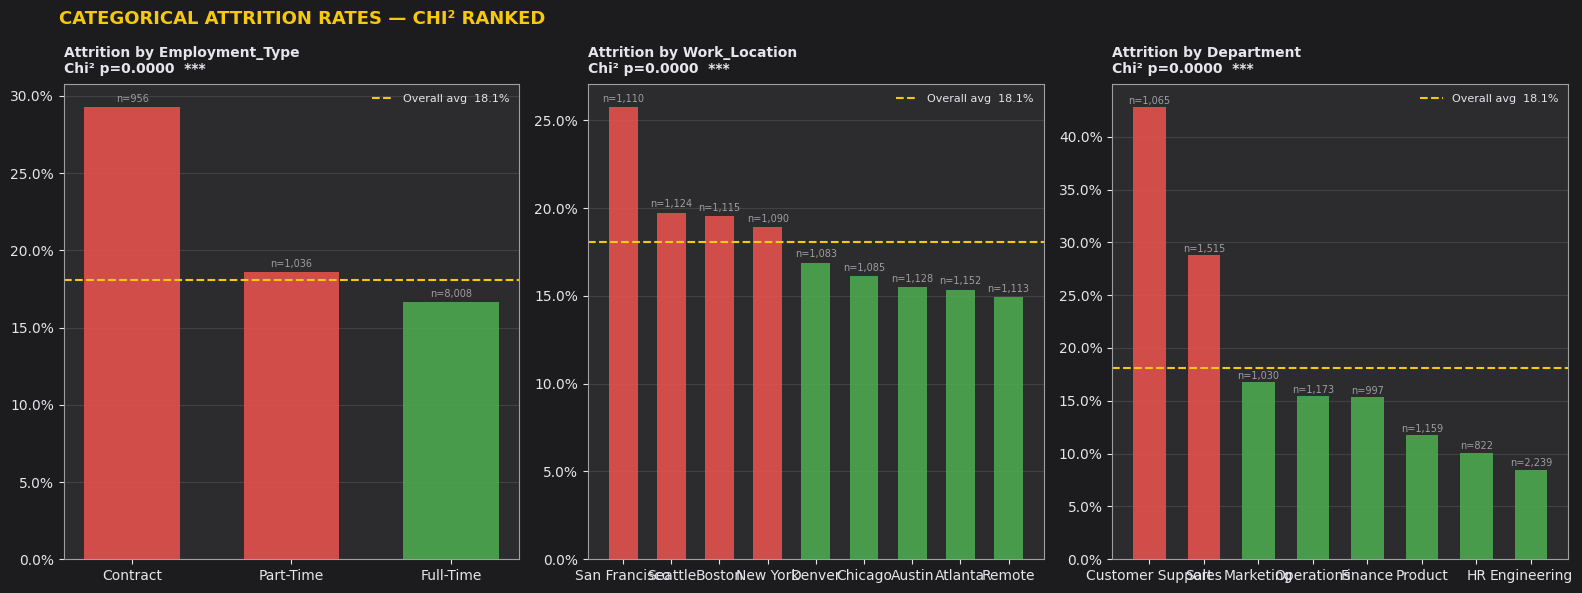

  Saved → outputs/06_categorical_attrition.png


In [13]:
# ── Plot 6 — Categorical attrition rates (Chi² ranked) ───────────────────────
cat_groups = {
    "Employment_Type": [c for c in df.columns if c.startswith("Employment_Type_")],
    "Work_Location":   [c for c in df.columns if c.startswith("Work_Location_")],
    "Department":      [c for c in df.columns if c.startswith("Department_")],
}

fig, axes = plt.subplots(1, len(cat_groups), figsize=(16, 6), facecolor=BG)
fig.suptitle("CATEGORICAL ATTRITION RATES — CHI² RANKED",
             color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

for ax, (group_name, cols) in zip(axes, cat_groups.items()):
    if not cols:
        ax.text(0.5, 0.5, "No columns found", ha="center", va="center",
                transform=ax.transAxes, color=NEUTRAL)
        continue

    rates, names, counts = [], [], []
    for col in cols:
        mask = df[col] == 1
        if mask.sum() < 10:
            continue
        rates.append(df.loc[mask, TARGET].mean())
        names.append(col.split("_")[-1])
        counts.append(int(mask.sum()))

    # Chi² significance test across category block
    sub      = df[cols + [TARGET]].dropna()
    observed = pd.crosstab(sub[cols].idxmax(axis=1), sub[TARGET])
    chi2_val, p, _, _ = chi2_contingency(observed)

    sort_idx = np.argsort(rates)[::-1]
    rates_s  = [rates[i] for i in sort_idx]
    names_s  = [names[i] for i in sort_idx]
    counts_s = [counts[i] for i in sort_idx]

    bar_colors = [LEAVE_COLOR if r > attrition_rate else STAY_COLOR for r in rates_s]
    bars = ax.bar(names_s, rates_s, color=bar_colors, alpha=0.85, width=0.6)
    ax.axhline(attrition_rate, color=ACCENT, ls="--", lw=1.5,
               label=f"Overall avg  {attrition_rate:.1%}")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for bar, count in zip(bars, counts_s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"n={count:,}", ha="center", fontsize=7, color=NEUTRAL)
    ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    styled_title(ax, f"Attrition by {group_name}", f"Chi² p={p:.4f}  {star}")

plt.tight_layout()
save_fig(fig, "06_categorical_attrition")


#### 5g. High-Risk Segment Discovery

The previous plots looked at one dimension at a time. This cell combines two continuous risk factors in a single scatter plot — pay competitiveness on the x-axis against other risk signals (tenure, satisfaction, engagement) on the y-axis — with each employee plotted as a dot coloured by outcome. The quadrant lines (drawn at each variable's median) divide the chart into four risk zones. The bottom-left quadrant (underpaid AND low tenure/satisfaction) is where the highest-risk employees concentrate.

**Technical note:** Points are semi-transparent (`alpha` 0.12 – 0.25) and rasterised for performance on large datasets. Quadrant lines are drawn at the dataset-wide median of each axis variable, making the quadrants robust to skewed distributions. The bottom-left quadrant annotation is hard-coded; its validity should be verified from the actual scatter pattern. If a risk factor column is absent from the encoded `df` (e.g. `Engagement` vs `Engagement_Level`), the column-search list should be updated in `risk_cols`.

**Business question:** What does the profile of the highest-risk employee look like — underpaid and disengaged, or something else?


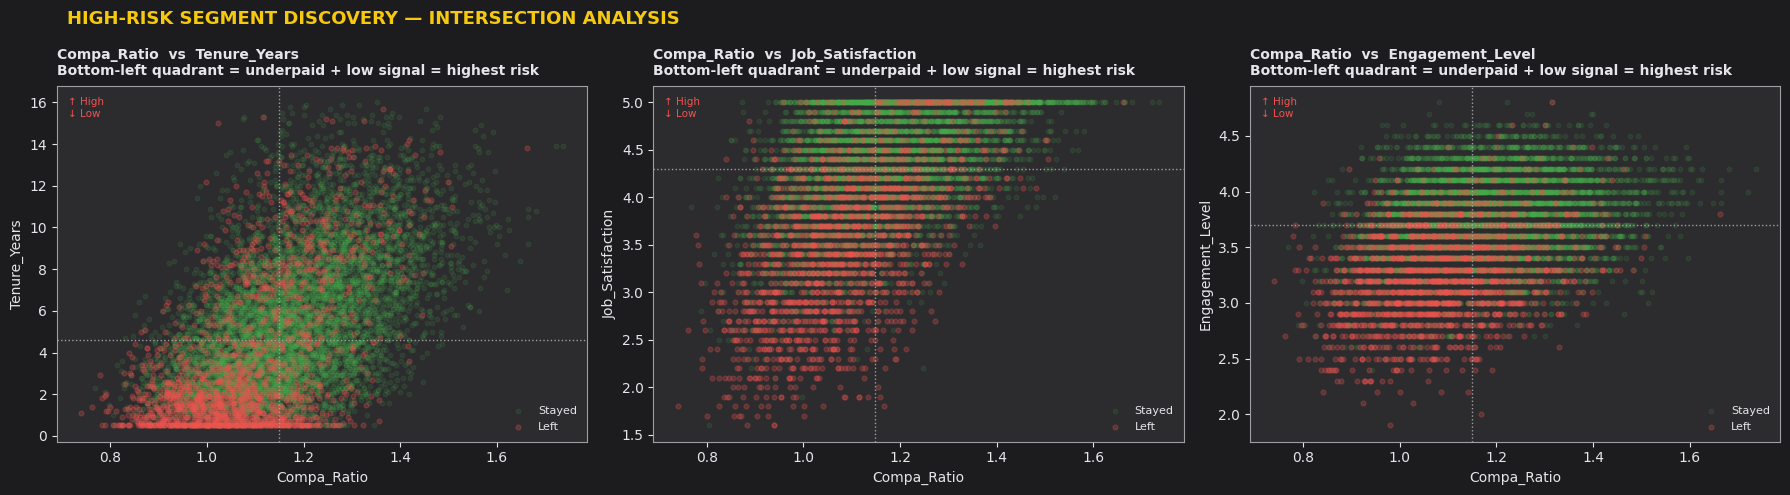

  Saved → outputs/07_risk_segment_scatter.png

────────────────────────────────────────────────────────────
  EDA Summary
────────────────────────────────────────────────────────────
  Attrition rate              : 18.1%
  Most correlated feature     : Job_Satisfaction  (|r|=0.483)
  Strongest survey signal     : Job_Satisfaction
  All EDA plots saved to      : outputs/


In [15]:
# ── Plot 7 — High-risk segment discovery scatter ─────────────────────────────
# Searches for Engagement_Level first, then Engagement as fallback
risk_cols = [
    "Compa_Ratio", "Tenure_Years", "Job_Satisfaction", "Engagement_Level", "Engagement"
]
available = [c for c in risk_cols if c in df.columns]
# Deduplicate while preserving order (Engagement_Level takes priority over Engagement)
seen = set()
available = [c for c in available if not (c in seen or seen.add(c))]

if len(available) >= 2:
    col1    = available[0]
    others  = available[1:4]          # up to 3 comparison axes
    n_plots = len(others)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5), facecolor=BG)
    if n_plots == 1:
        axes = [axes]
    fig.suptitle("HIGH-RISK SEGMENT DISCOVERY — INTERSECTION ANALYSIS",
                 color=ACCENT, fontsize=13, fontweight="bold", x=0.04, ha="left")

    for ax, col2 in zip(axes, others):
        stayed_s = df.loc[df[TARGET] == 0, [col1, col2]].dropna()
        left_s   = df.loc[df[TARGET] == 1, [col1, col2]].dropna()
        ax.scatter(stayed_s[col1], stayed_s[col2], c=STAY_COLOR, alpha=0.12, s=10,
                   rasterized=True, label="Stayed")
        ax.scatter(left_s[col1],   left_s[col2],   c=LEAVE_COLOR, alpha=0.25, s=12,
                   rasterized=True, label="Left")
        ax.axvline(df[col1].median(), color=NEUTRAL, ls=":", lw=1)
        ax.axhline(df[col2].median(), color=NEUTRAL, ls=":", lw=1)
        ax.set_xlabel(col1)
        ax.set_ylabel(col2)
        ax.text(0.02, 0.97, "↑ High\n↓ Low", transform=ax.transAxes,
                color=LEAVE_COLOR, fontsize=7.5, va="top")
        ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8,
                  loc="lower right")
        styled_title(ax, f"{col1}  vs  {col2}",
                     "Bottom-left quadrant = underpaid + low signal = highest risk")

    plt.tight_layout()
    save_fig(fig, "07_risk_segment_scatter")
else:
    print(f"Skipping risk scatter — fewer than 2 of {risk_cols} found in df.")

# ── EDA summary ───────────────────────────────────────────────────────────────
print_section("EDA Summary")
print(f"  Attrition rate              : {attrition_rate:.1%}")
print(f"  Most correlated feature     : {corr_with_target.index[0]}  (|r|={corr_with_target.iloc[0]:.3f})")

survey_candidates = [
    "Job_Satisfaction", "Work_Life_Balance", "Management_Support",
    "Career_Development", "Engagement_Level",
]
survey_present = [c for c in survey_candidates if c in df.columns]
if survey_present:
    pb_corrs = [abs(pointbiserialr(df[TARGET], df[c].fillna(df[c].median()))[0])
                for c in survey_present]
    print(f"  Strongest survey signal     : {survey_present[int(np.argmax(pb_corrs))]}")
print(f"  All EDA plots saved to      : {OUTPUT_DIR}/")


### 6. Dtype & Precision Audit

**In plain terms:** Every number in our dataset must be stored in a specific numeric format before the model can read it. This cell checks for any columns that are still stored as text and then converts all values to *float32* — the compact numeric format that XGBoost's engine expects. If anything is still text at this point, we get a clear error message rather than a cryptic crash later.

**Technically:** XGBoost's C++ tree-construction kernel requires contiguous `float32` (or `float64`) arrays. Boolean-typed OHE dummy columns and any residual object-typed columns either raise a `ValueError` at `.fit()` time or get silently misinterpreted. We audit *before* the train/test split so that any encoding gap surfaces immediately — fail fast, fail clearly (§1, §2). Casting to `float32` instead of `float64` halves memory footprint and accelerates GPU matrix ops.

> **Inputs:** `model_df` — fully encoded DataFrame with mixed dtypes  
> **Outputs:** `model_df` — identical shape; all feature columns now `dtype=float32`; raises `ValueError` if any object-type column remains

In [16]:
print_section("§6  Dtype & Precision Audit")

feature_cols = [c for c in model_df.columns if c != TARGET_COL]

# Fail-fast: any residual object column raises before the expensive split/train cycle (§1, §2)
object_cols = model_df[feature_cols].select_dtypes(include="object").columns.tolist()
if object_cols:
    raise ValueError(
        f"Object-type columns remain after encoding — XGBoost cannot ingest these: {object_cols}\n"
        "Add them to NOMINAL_COLS or ORDINAL_MAPS before this cell runs."
    )

# Cast all feature columns to float32 (halves memory vs float64, required for XGBoost C++ kernel)
model_df[feature_cols] = model_df[feature_cols].astype(np.float32)

dtype_counts = model_df[feature_cols].dtypes.value_counts()
print(f"Feature columns : {len(feature_cols)}")
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):<10}  {count:>4} columns")
print("Dtype audit passed ✓  —  all feature columns are float32")


────────────────────────────────────────────────────────────
  §6  Dtype & Precision Audit
────────────────────────────────────────────────────────────
Feature columns : 33
  float32       33 columns
Dtype audit passed ✓  —  all feature columns are float32


### 7. Stratified Train / Validation / Test Split

**In plain terms:** We divide our ~10,000 employee records into three non-overlapping pools: **train** (used to teach the model), **validation** (used to tune hyperparameters *without* peeking at test data), and **test** (sealed until the final evaluation). Crucially, we make sure each pool has roughly the same proportion of employees who left — so no pool accidentally has too few "left" examples to be statistically meaningful.

**Technically:** `train_test_split(..., stratify=y)` invokes `StratifiedShuffleSplit` internally, enforcing that $P(Y{=}1)$ is identical across all three sets. Without stratification, a 15% minority class in an 80/20 split can land near-zero minority samples in the test set by chance — making AUC and Precision-Recall curves undefined or misleading. The validation set is carved from the training portion *before* applying SMOTE — oversampled synthetic rows must never contaminate the validation or test pools (§6, §8, §17).

**Protected-attribute alignment:** `train_test_split` cannot reliably split more than two paired arrays across library versions. We use **index alignment** (`protected_df.loc[X_train.index]`) after the main split to correctly slice `protected_df` — no data leakage, no index mismatch (§8, §17).

> **Inputs:** `model_df` (float32, all features encoded), `protected_df`  
> **Outputs:** `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `X_train_raw`, `y_train_raw`, `protected_train_raw`, `protected_val`, `protected_test`

In [17]:
print_section("§7  Stratified Train / Validation / Test Split")

X = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL]

# ── Step 1: Stratified 80/20 train vs test split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,          # enforces identical class ratio (§8)
)

# ── Step 2: Carve validation from train — BEFORE SMOTE (§6, §17) ─────────────
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_train, y_train,
    test_size    = VAL_SIZE,   # uses global config constant
    random_state = RANDOM_STATE,
    stratify     = y_train,
)

# ── Step 3: Index-align protected attributes to each split (§8) ──────────────
protected_train     = protected_df.loc[X_train.index]
protected_test      = protected_df.loc[X_test.index]
protected_train_raw = protected_df.loc[X_train_raw.index]
protected_val       = protected_df.loc[X_val.index]

# ── Step 4: Integrity assertions ─────────────────────────────────────────────
assert (X_train.index     == protected_train.index).all(),     "Index mismatch: X_train ↔ protected_train"
assert (X_train_raw.index == protected_train_raw.index).all(), "Index mismatch: X_train_raw ↔ protected_train_raw"
assert (X_val.index       == protected_val.index).all(),       "Index mismatch: X_val ↔ protected_val"
assert (X_test.index      == protected_test.index).all(),      "Index mismatch: X_test ↔ protected_test"

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Pool':<26} {'Rows':>6}  {'Attrition%':>10}")
print("─" * 46)
for label, y_ in [
    ("Full dataset",       y),
    ("Train (full)",       y_train),
    ("  └─ Train (pre-SMOTE)", y_train_raw),
    ("  └─ Validation",   y_val),
    ("Test",               y_test),
]:
    print(f"{label:<26} {len(y_):>6}  {y_.mean()*100:>9.2f}%")


────────────────────────────────────────────────────────────
  §7  Stratified Train / Validation / Test Split
────────────────────────────────────────────────────────────
Pool                         Rows  Attrition%
──────────────────────────────────────────────
Full dataset                10000      18.08%
Train (full)                 8000      18.07%
  └─ Train (pre-SMOTE)       6800      18.07%
  └─ Validation              1200      18.08%
Test                         2000      18.10%


### 8. Class Imbalance Handling — SMOTE & `scale_pos_weight`

**In plain terms:** Only about 15% of employees in our dataset left the company. If we train on this as-is, the model quickly learns that predicting "nobody leaves" scores 85% accuracy — but it catches zero actual leavers. We fix this two ways: (1) we compute a *weight multiplier* that tells XGBoost to treat each "left" example as if it were ~5–6 separate examples, and (2) we use SMOTE to synthetically create new "left" examples by interpolating between real ones — balancing the training pool before it ever reaches the model.

**Technically — `scale_pos_weight`:** XGBoost minimises the regularised objective $\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$. With class imbalance the gradient signal from the minority class is proportionally weaker. `scale_pos_weight` scales both the gradient $g_i$ and Hessian $h_i$ for positive examples by $w = N_{\text{neg}} / N_{\text{pos}}$, restoring gradient balance. Computed on `y_train` (the full training set **before** SMOTE) to prevent test-set leakage (§6, §9).

**Technically — SMOTE:** Synthetic Minority Over-sampling Technique generates synthetic positive-class rows by linearly interpolating between a minority sample and one of its $k$ nearest neighbours in feature space. Applied exclusively to `X_train_raw`/`y_train_raw` — the validation and test sets are never touched (§6, §17).

> **Inputs:** `y_train` (full train labels), `X_train_raw` / `y_train_raw` (pre-val train)  
> **Outputs:** `scale_pos_weight` (float), `X_train_sm` / `y_train_sm` (SMOTE-balanced arrays)

In [18]:
print_section("§8  Class Imbalance Handling — scale_pos_weight + SMOTE")

# ── scale_pos_weight (computed on full y_train, before SMOTE) ─────────────────
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

if n_pos == 0:
    raise ValueError("No positive samples in training set — check your data or stratification.")

scale_pos_weight = n_neg / n_pos   # w = N_neg / N_pos (§9)

print(f"Pre-SMOTE training set:")
print(f"  Negatives (stayed) : {n_neg:,}")
print(f"  Positives (left)   : {n_pos:,}")
print(f"  scale_pos_weight   : {scale_pos_weight:.4f}  (pass to XGBoost/CatBoost)")

# ── SMOTE oversampling on X_train_raw / y_train_raw ───────────────────────────
# SMOTE must NEVER see X_val or X_test — that would be data leakage (§6, §17)
if SMOTE is None:
    raise RuntimeError("imbalanced-learn is required. Install with: pip install imbalanced-learn")

sm = SMOTE(
    sampling_strategy="auto",   # oversample minority to match majority
    k_neighbors=5,
    random_state=RANDOM_STATE,
)
X_train_sm, y_train_sm = sm.fit_resample(X_train_raw, y_train_raw)

# SMOTE returns numpy arrays; restore column names and dtypes
X_train_sm = pd.DataFrame(X_train_sm, columns=X_train_raw.columns).astype(np.float32)
y_train_sm = pd.Series(y_train_sm, name=y_train_raw.name)

neg_sm = (y_train_sm == 0).sum()
pos_sm = (y_train_sm == 1).sum()
scale_pos_weight_sm = neg_sm / max(pos_sm, 1)   # ≈ 1.0 after SMOTE

print(f"\nPost-SMOTE training set (X_train_sm):")
print(f"  Shape    : {X_train_sm.shape}")
print(f"  Class 0  : {neg_sm:,}  |  Class 1 : {pos_sm:,}")
print(f"  scale_pos_weight post-SMOTE : {scale_pos_weight_sm:.4f}  (use 1.0 — classes balanced)")


────────────────────────────────────────────────────────────
  §8  Class Imbalance Handling — scale_pos_weight + SMOTE
────────────────────────────────────────────────────────────
Pre-SMOTE training set:
  Negatives (stayed) : 6,554
  Positives (left)   : 1,446
  scale_pos_weight   : 4.5325  (pass to XGBoost/CatBoost)

Post-SMOTE training set (X_train_sm):
  Shape    : (11142, 33)
  Class 0  : 5,571  |  Class 1 : 5,571
  scale_pos_weight post-SMOTE : 1.0000  (use 1.0 — classes balanced)


### 9a. XGBoost Hyperparameter Tuning — Optuna

**In plain terms:** Instead of hand-picking model settings such as tree depth and learning speed, we let Optuna run dozens of experiments automatically. Each experiment trains a candidate XGBoost model, scores it on the validation set, and reports back. Optuna learns from earlier experiments to propose better settings next time — like a smart search that narrows in on the best configuration.

**Technically:** Optuna's Tree-structured Parzen Estimator (TPE) sampler models $p(\lambda \mid \text{good})$ and $p(\lambda \mid \text{bad})$ as kernel-density estimates, proposing candidates that maximise $\ell(\lambda) = p_l / p_g$. The objective metric is **Average Precision (PR-AUC)** on `X_val`/`y_val` — a better signal than ROC-AUC when the positive class is rare. `scale_pos_weight=1.0` is fixed because SMOTE already balanced the training distribution. A `MedianPruner` kills underperforming trials early, reducing wall-time without bias.

> **Inputs:** `X_train_sm`, `y_train_sm` (SMOTE-balanced), `X_val`, `y_val`  
> **Outputs:** `xgb_model` (fitted), `xgb_params` (best hyperparameters), `xgb_study` (Optuna study object)

In [19]:
print_section("§9a  XGBoost — Optuna Tuning")

def optimize_xgboost(
    X_tr, y_tr, X_v, y_v,
    n_trials: int = 50,
) -> Tuple[Any, Dict[str, Any], Any]:
    if optuna is None or XGBClassifier is None:
        raise RuntimeError("XGBoost / Optuna unavailable.")

    def objective(trial: optuna.Trial) -> float:
        params = dict(
            n_estimators       = trial.suggest_int("n_estimators", 200, 800),
            max_depth          = trial.suggest_int("max_depth", 3, 10),
            learning_rate      = trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            subsample          = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree   = trial.suggest_float("colsample_bytree", 0.4, 1.0),
            colsample_bylevel  = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
            min_child_weight   = trial.suggest_float("min_child_weight", 1, 30),
            gamma              = trial.suggest_float("gamma", 0.0, 5.0),
            reg_alpha          = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda         = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            max_delta_step     = trial.suggest_int("max_delta_step", 0, 5),
            # Fixed
            scale_pos_weight   = 1.0,   # classes balanced via SMOTE (§9)
            eval_metric        = "aucpr",
            tree_method        = "hist",
            random_state       = RANDOM_STATE,
            n_jobs             = -1,
            use_label_encoder  = False,
        )
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        return average_precision_score(y_v, model.predict_proba(X_v)[:, 1])

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=10),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = {**study.best_params,
                   "scale_pos_weight": 1.0, "eval_metric": "aucpr",
                   "tree_method": "hist", "random_state": RANDOM_STATE,
                   "n_jobs": -1, "use_label_encoder": False}

    best_model = XGBClassifier(**best_params)
    best_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    return best_model, best_params, study


xgb_model, xgb_params, xgb_study = optimize_xgboost(
    X_train_sm, y_train_sm, X_val, y_val, n_trials=50
)
print(f"XGBoost best val PR-AUC : {xgb_study.best_value:.4f}")
print("Best params:", json.dumps(
    {k: round(v, 6) if isinstance(v, float) else v for k, v in xgb_params.items()}, indent=2
))


────────────────────────────────────────────────────────────
  §9a  XGBoost — Optuna Tuning
────────────────────────────────────────────────────────────


Best trial: 32. Best value: 0.628255: 100%|██████████| 50/50 [00:39<00:00,  1.28it/s]


XGBoost best val PR-AUC : 0.6283
Best params: {
  "n_estimators": 800,
  "max_depth": 5,
  "learning_rate": 0.1247,
  "subsample": 0.712926,
  "colsample_bytree": 0.626763,
  "colsample_bylevel": 0.477061,
  "min_child_weight": 16.447677,
  "gamma": 4.016764,
  "reg_alpha": 2e-06,
  "reg_lambda": 0.001584,
  "max_delta_step": 0,
  "scale_pos_weight": 1.0,
  "eval_metric": "aucpr",
  "tree_method": "hist",
  "random_state": 42,
  "n_jobs": -1,
  "use_label_encoder": false
}


### 9b. RandomForest Hyperparameter Tuning — Optuna

**In plain terms:** Same automated search as XGBoost, but now for a Random Forest — an ensemble of decision trees where each tree is trained on a random data sample and a random subset of features. Because Random Forest can't directly use a `scale_pos_weight` parameter, we configure it with `class_weight="balanced_subsample"` which achieves equivalent effect by reweighting samples inside each bootstrap.

**Technically:** `class_weight="balanced_subsample"` recomputes loss weights per bootstrap sample rather than globally — empirically superior to `"balanced"` for moderately imbalanced tree ensembles. The objective remains PR-AUC on `X_val`. No pruner is applied here since RF trials are fast and variance between trials is lower than gradient-boosted models.

> **Inputs:** `X_train_sm`, `y_train_sm`, `X_val`, `y_val`  
> **Outputs:** `rf_model`, `rf_params`, `rf_study`

In [20]:
print_section("§9b  RandomForest — Optuna Tuning")

def optimize_random_forest(
    X_tr, y_tr, X_v, y_v,
    n_trials: int = 30,
) -> Tuple[Any, Dict[str, Any], Any]:
    if optuna is None:
        raise RuntimeError("Optuna unavailable.")

    def objective(trial: optuna.Trial) -> float:
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 300, 1000),
            max_depth         = trial.suggest_int("max_depth", 5, 30),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 12),
            max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, None]),
            max_samples       = trial.suggest_float("max_samples", 0.6, 1.0),
            # Fixed
            class_weight      = "balanced_subsample",  # recomputed per bootstrap (§9)
            bootstrap         = True,
            random_state      = RANDOM_STATE,
            n_jobs            = -1,
        )
        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)
        return average_precision_score(y_v, model.predict_proba(X_v)[:, 1])

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = {**study.best_params,
                   "class_weight": "balanced_subsample", "bootstrap": True,
                   "random_state": RANDOM_STATE, "n_jobs": -1}

    best_model = RandomForestClassifier(**best_params)
    best_model.fit(X_tr, y_tr)
    return best_model, best_params, study


rf_model, rf_params, rf_study = optimize_random_forest(
    X_train_sm, y_train_sm, X_val, y_val, n_trials=30
)
print(f"RandomForest best val PR-AUC : {rf_study.best_value:.4f}")
print("Best params:", json.dumps(
    {k: round(v, 6) if isinstance(v, float) else v for k, v in rf_params.items()}, indent=2
))


────────────────────────────────────────────────────────────
  §9b  RandomForest — Optuna Tuning
────────────────────────────────────────────────────────────


Best trial: 12. Best value: 0.607399: 100%|██████████| 30/30 [01:32<00:00,  3.07s/it]


RandomForest best val PR-AUC : 0.6074
Best params: {
  "n_estimators": 455,
  "max_depth": 23,
  "min_samples_split": 11,
  "min_samples_leaf": 8,
  "max_features": "sqrt",
  "max_samples": 0.864342,
  "class_weight": "balanced_subsample",
  "bootstrap": true,
  "random_state": 42,
  "n_jobs": -1
}


### 9c. CatBoost Hyperparameter Tuning — Optuna

**In plain terms:** CatBoost is a gradient-boosted tree library developed by Yandex that is particularly strong when data has many categorical features. Like the other two searches, Optuna probes its hyperparameter space to find the configuration that achieves the best score on our validation set.

**Technically:** CatBoost handles class imbalance natively via `auto_class_weights="Balanced"`, so no SMOTE is strictly required for it — but we still use `X_train_sm` for consistency and a fair comparison with XGBoost and RF. `use_best_model=True` combined with `od_type="Iter"` / `od_wait=30` implements built-in early stopping: training rolls back to the iteration with the best validation AUC, preventing over-fitting without an explicit `n_estimators` cap.

> **Inputs:** `X_train_sm`, `y_train_sm`, `X_val`, `y_val`  
> **Outputs:** `cb_model`, `cb_params`, `cb_study`

In [21]:
print_section("§9c  CatBoost — Optuna Tuning")

def optimize_catboost(
    X_tr, y_tr, X_v, y_v,
    n_trials: int = 30,
) -> Tuple[Any, Dict[str, Any], Any]:
    if optuna is None or CatBoostClassifier is None:
        raise RuntimeError("CatBoost / Optuna unavailable.")

    def objective(trial: optuna.Trial) -> float:
        params = dict(
            iterations          = trial.suggest_int("iterations", 300, 1000),
            depth               = trial.suggest_int("depth", 4, 10),
            learning_rate       = trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            l2_leaf_reg         = trial.suggest_float("l2_leaf_reg", 1.0, 20.0),
            bagging_temperature = trial.suggest_float("bagging_temperature", 0.0, 1.0),
            random_strength     = trial.suggest_float("random_strength", 0.0, 2.0),
            border_count        = trial.suggest_int("border_count", 32, 255),
            # Fixed
            auto_class_weights  = "Balanced",   # native imbalance handling (§9)
            loss_function       = "Logloss",
            eval_metric         = "AUC",
            od_type             = "Iter",
            od_wait             = 30,            # early-stop patience
            random_seed         = RANDOM_STATE,
            verbose             = False,
            thread_count        = -1,
        )
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_v, y_v), use_best_model=True, verbose=False)
        return average_precision_score(y_v, model.predict_proba(X_v)[:, 1])

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=8),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = {**study.best_params,
                   "auto_class_weights": "Balanced", "loss_function": "Logloss",
                   "eval_metric": "AUC", "od_type": "Iter", "od_wait": 30,
                   "random_seed": RANDOM_STATE, "verbose": False, "thread_count": -1}

    best_model = CatBoostClassifier(**best_params)
    best_model.fit(X_tr, y_tr, eval_set=(X_v, y_v), use_best_model=True, verbose=False)
    return best_model, best_params, study


cb_model, cb_params, cb_study = optimize_catboost(
    X_train_sm, y_train_sm, X_val, y_val, n_trials=30
)
print(f"CatBoost best val PR-AUC : {cb_study.best_value:.4f}")
print("Best params:", json.dumps(
    {k: round(v, 6) if isinstance(v, float) else v for k, v in cb_params.items()}, indent=2
))


────────────────────────────────────────────────────────────
  §9c  CatBoost — Optuna Tuning
────────────────────────────────────────────────────────────


Best trial: 16. Best value: 0.625275: 100%|██████████| 30/30 [00:47<00:00,  1.57s/it]


CatBoost best val PR-AUC : 0.6253
Best params: {
  "iterations": 779,
  "depth": 7,
  "learning_rate": 0.028061,
  "l2_leaf_reg": 8.315555,
  "bagging_temperature": 0.309701,
  "random_strength": 1.267761,
  "border_count": 205,
  "auto_class_weights": "Balanced",
  "loss_function": "Logloss",
  "eval_metric": "AUC",
  "od_type": "Iter",
  "od_wait": 30,
  "random_seed": 42,
  "verbose": false,
  "thread_count": -1
}


### 10. Optuna Convergence Plots

**In plain terms:** After all three model searches finish, we plot how the best score discovered so far improved with each trial. A flat line early on means the search found a good region quickly; continued improvements late in the search suggest more trials would still help. These charts let us decide whether 50 trials was enough.

**Technically:** For each study, we extract `trial.value` for all completed trials and compute the running maximum (`np.maximum.accumulate`). Semi-transparent scatter points show individual trial PR-AUC values; the solid line shows the cumulative best. A steep initial rise followed by a plateau indicates TPE converged to a stable optimum.

> **Inputs:** `xgb_study`, `rf_study`, `cb_study`  
> **Outputs:** [outputs/optuna_history.png](outputs/optuna_history.png) + inline figure


────────────────────────────────────────────────────────────
  §10  Optuna Convergence Plots
────────────────────────────────────────────────────────────


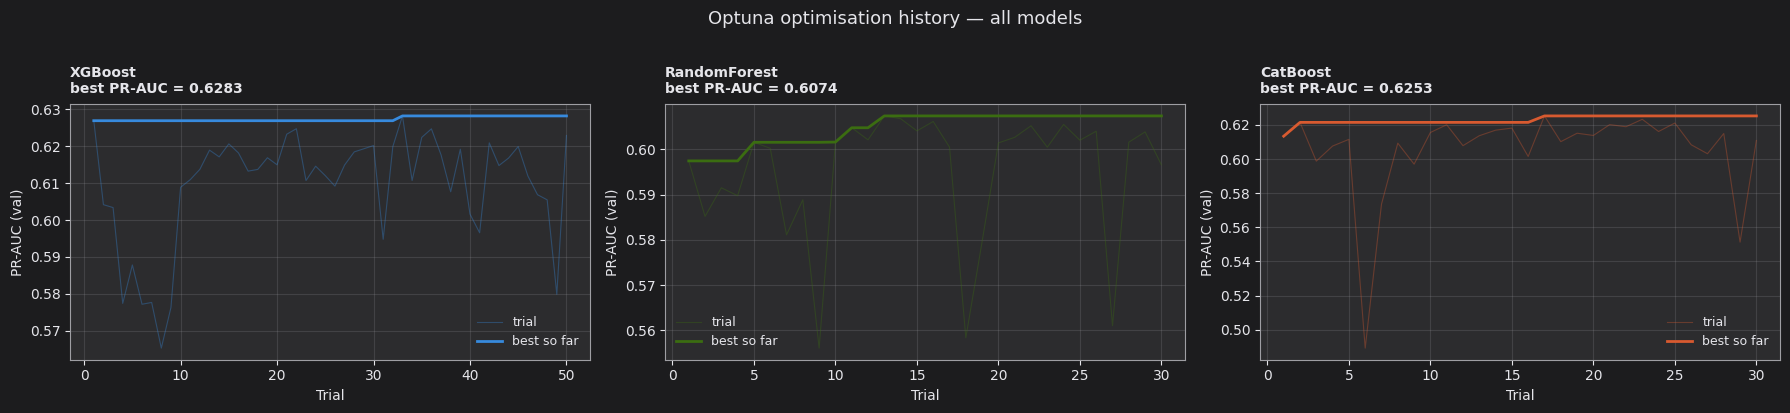

  Saved → outputs/optuna_history.png


In [22]:
print_section("§10  Optuna Convergence Plots")

models_dict   = {"XGBoost": xgb_model, "RandomForest": rf_model, "CatBoost": cb_model}
studies_dict  = {"XGBoost": xgb_study, "RandomForest": rf_study, "CatBoost": cb_study}
best_params_all = {"XGBoost": xgb_params, "RandomForest": rf_params, "CatBoost": cb_params}

palette = {"XGBoost": "#378ADD", "RandomForest": "#3B6D11", "CatBoost": "#D85A30"}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor=BG)
for ax, (name, study) in zip(axes, studies_dict.items()):
    values       = [t.value for t in study.trials if t.value is not None]
    best_so_far  = np.maximum.accumulate(values)
    ax.set_facecolor(CARD_BG)
    ax.plot(range(1, len(values) + 1), values,
            alpha=0.35, color=palette[name], linewidth=0.8, label="trial")
    ax.plot(range(1, len(best_so_far) + 1), best_so_far,
            color=palette[name], linewidth=2, label="best so far")
    styled_title(ax, name, f"best PR-AUC = {max(values):.4f}")
    ax.set_xlabel("Trial", color=TEXT); ax.set_ylabel("PR-AUC (val)", color=TEXT)
    ax.tick_params(colors=TEXT); ax.legend(fontsize=9)
    ax.grid(alpha=0.20)

fig.suptitle("Optuna optimisation history — all models", color=TEXT, fontsize=13, y=1.02)
plt.tight_layout()
save_fig(fig, "optuna_history")

### 11. Model Evaluation on Test Set

**In plain terms:** Now we measure how well each model performs on employees it has *never seen before* — the held-out test set. We look at six things: how good the model is at ordering employees by risk (ROC-AUC), how precisely it identifies those who actually left (PR-AUC), how balanced precision and recall are at the best threshold (F1), calibration quality (Brier score), and how much better than chance the top-20% highest-risk employees are at actually being leavers (Lift@20%). The decision threshold used is chosen on the *validation* set — the test set is only touched once, right here.

**Technically:** Threshold optimisation maximises $F_1 = \frac{2 \cdot P \cdot R}{P + R}$ over the precision-recall curve computed on `X_val`/`y_val`. That threshold is then frozen and applied to `X_test`. This correctly simulates production deployment: you tune the operating point offline (val) and measure real-world performance on the sealed set (test). Six diagnostic plots per model — confusion matrix, ROC, PR curve, F1-vs-threshold, P/R vs threshold, and score distribution — are saved to disk.

> **Inputs:** `models_dict`, `X_val`, `y_val`, `X_test`, `y_test`  
> **Outputs:** `evaluation_rows` (list of dicts), per-model diagnostic plots in [outputs/](outputs/)


────────────────────────────────────────────────────────────
  §11  Model Evaluation — Test Set
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
    Evaluating: XGBoost
────────────────────────────────────────────────────────────


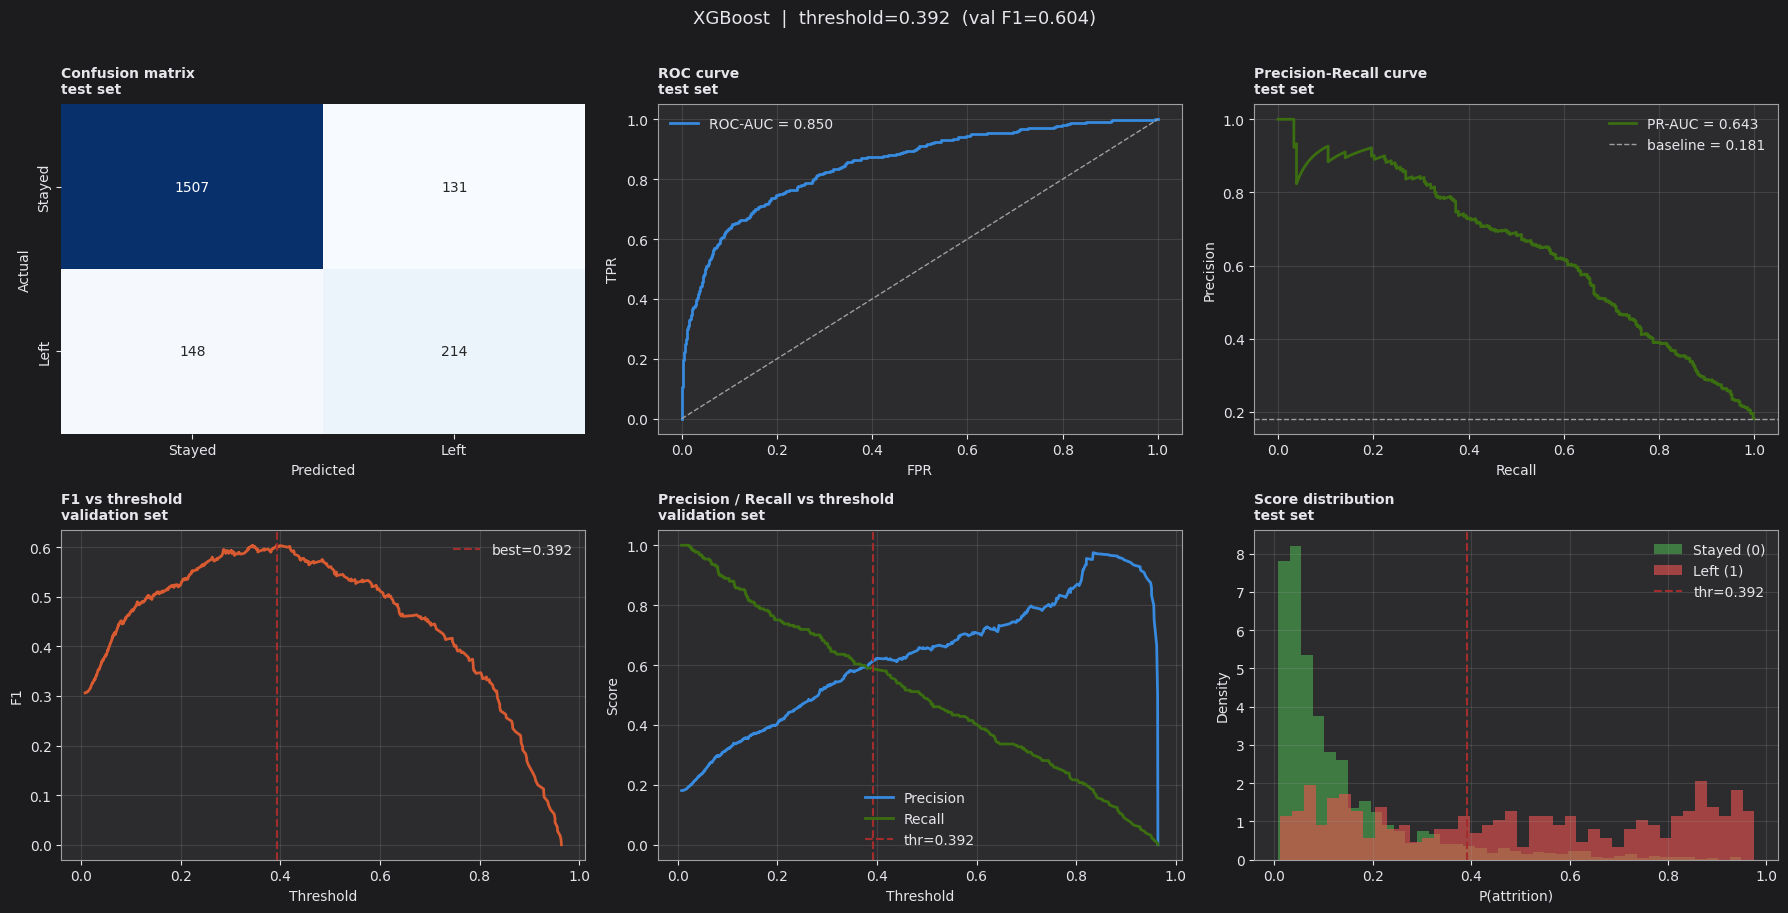

  Saved → outputs/xgboost_eval.png
              precision    recall  f1-score   support

      Stayed       0.91      0.92      0.92      1638
        Left       0.62      0.59      0.61       362

    accuracy                           0.86      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.86      0.86      0.86      2000


────────────────────────────────────────────────────────────
    Evaluating: RandomForest
────────────────────────────────────────────────────────────


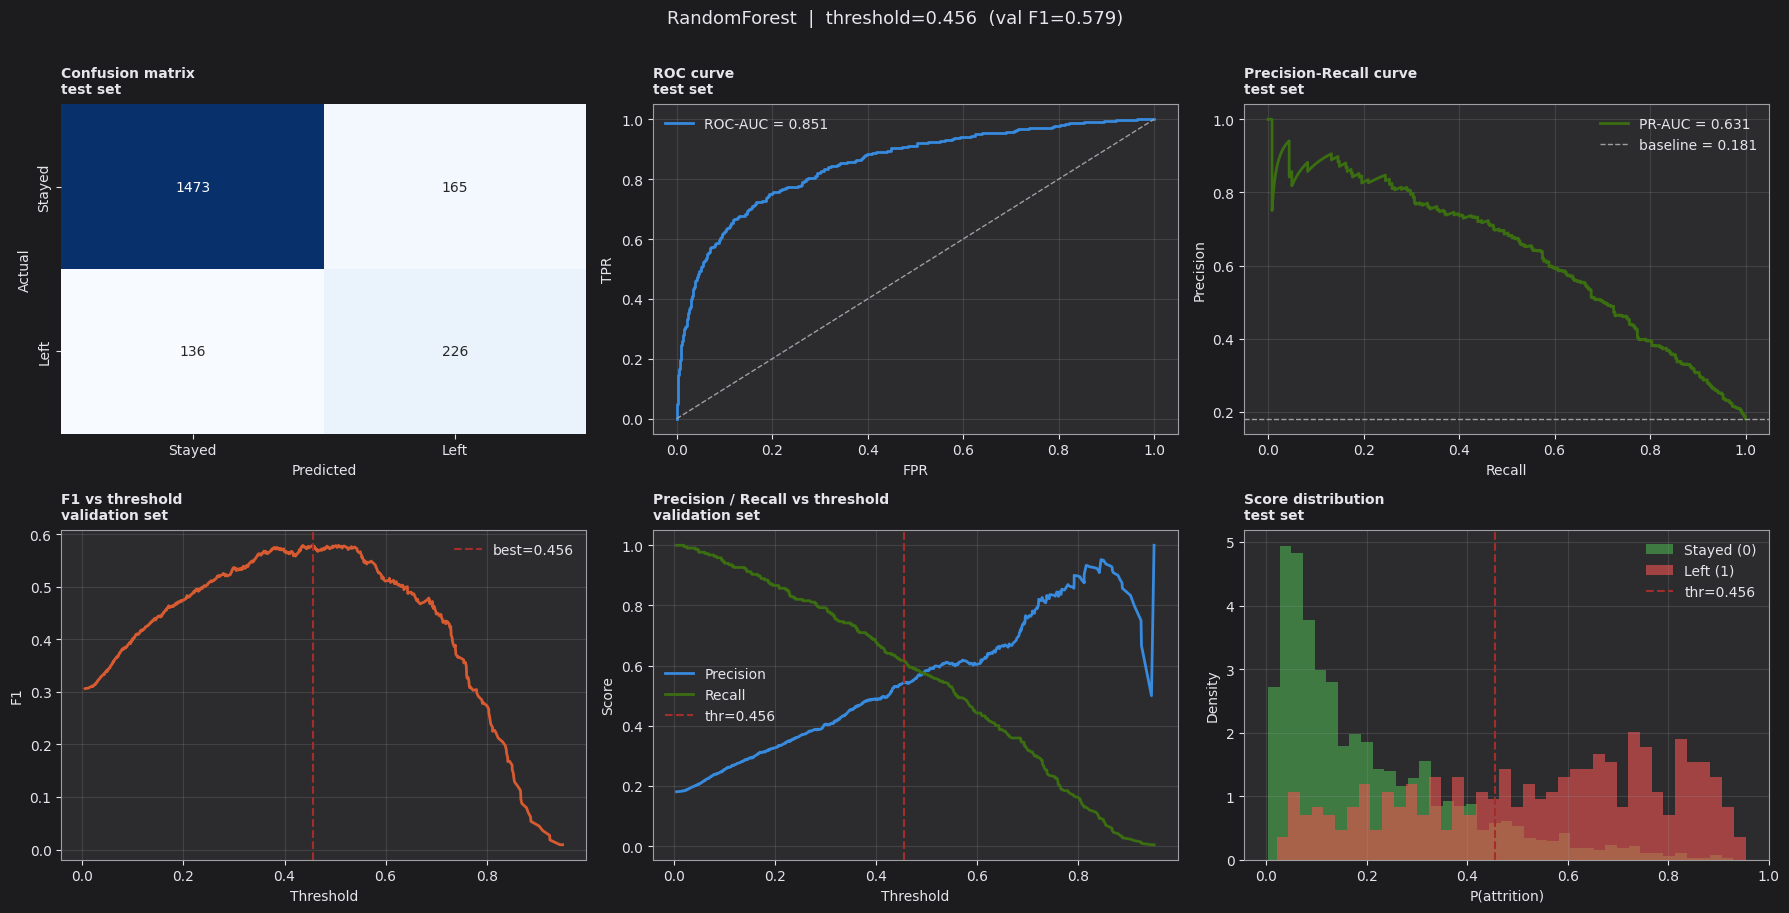

  Saved → outputs/randomforest_eval.png
              precision    recall  f1-score   support

      Stayed       0.92      0.90      0.91      1638
        Left       0.58      0.62      0.60       362

    accuracy                           0.85      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.85      0.85      0.85      2000


────────────────────────────────────────────────────────────
    Evaluating: CatBoost
────────────────────────────────────────────────────────────


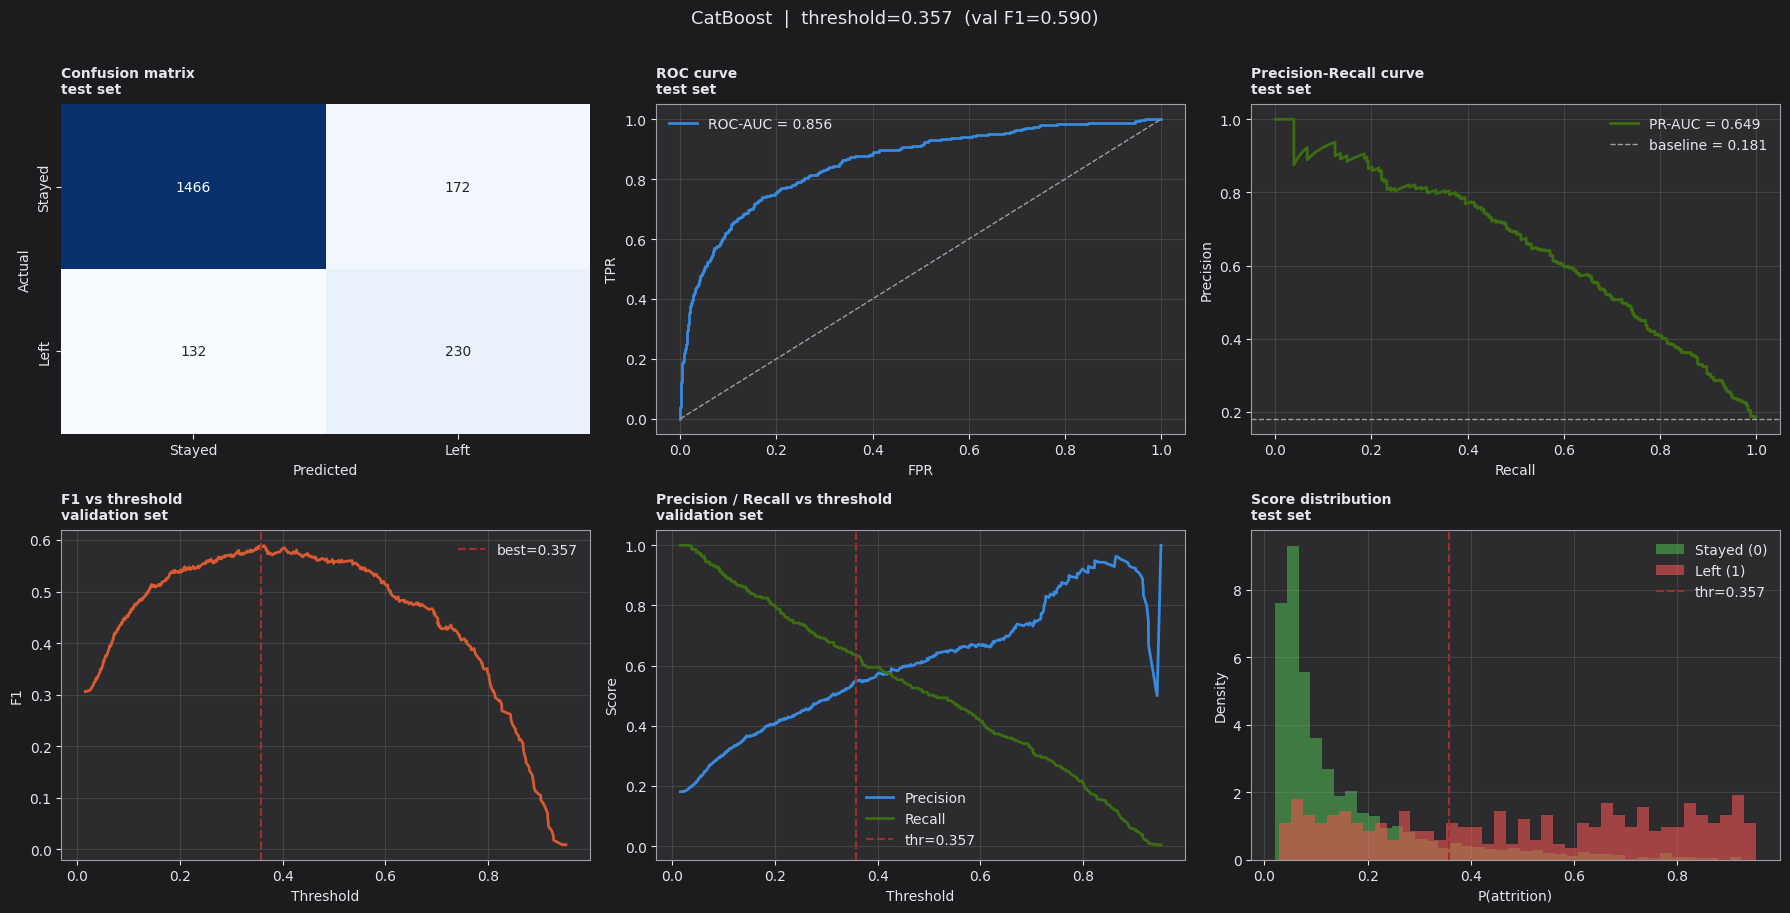

  Saved → outputs/catboost_eval.png
              precision    recall  f1-score   support

      Stayed       0.92      0.89      0.91      1638
        Left       0.57      0.64      0.60       362

    accuracy                           0.85      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.85      0.85      0.85      2000



In [23]:
print_section("§11  Model Evaluation — Test Set")

def business_lift(y_true: np.ndarray, y_prob: np.ndarray, top_pct: float = 0.20) -> float:
    """Lift at top percentile vs. random baseline."""
    k = max(1, int(len(y_true) * top_pct))
    idx = np.argsort(-y_prob)[:k]
    return float(y_true[idx].mean() / max(y_true.mean(), 1e-9))


def find_best_threshold(
    y_true: np.ndarray, y_prob: np.ndarray
) -> Tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """Return threshold that maximises F1 on the given set."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = (2 * precision[:-1] * recall[:-1]
           / np.maximum(precision[:-1] + recall[:-1], 1e-9))
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx]), precision, recall, thresholds


def evaluate_model(
    name: str, model: Any,
    X_v: pd.DataFrame, y_v: pd.Series,
    X_te: pd.DataFrame, y_te: pd.Series,
) -> Dict[str, Any]:
    """Evaluate one model; threshold chosen on val, metrics reported on test (§12)."""

    # ── threshold selection on val — test set never touched here ─────────────
    val_prob = model.predict_proba(X_v)[:, 1]
    thr, val_best_f1, p_val, r_val, thr_val = find_best_threshold(y_v.values, val_prob)

    # ── test inference ────────────────────────────────────────────────────────
    test_prob = model.predict_proba(X_te)[:, 1]
    test_pred = (test_prob >= thr).astype(int)

    roc_auc = roc_auc_score(y_te, test_prob)
    pr_auc  = average_precision_score(y_te, test_prob)
    f1      = f1_score(y_te, test_pred)
    brier   = brier_score_loss(y_te, test_prob)
    lift20  = business_lift(y_te.values, test_prob, top_pct=0.20)

    # ── diagnostic plots (6-panel) ────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), facecolor=BG)
    fig.suptitle(f"{name}  |  threshold={thr:.3f}  (val F1={val_best_f1:.3f})",
                 fontsize=13, color=TEXT, y=1.01)
    for ax in axes.flat:
        ax.set_facecolor(CARD_BG)
        ax.tick_params(colors=TEXT)

    # Confusion matrix
    cm = confusion_matrix(y_te, test_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0], cbar=False,
                xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
    styled_title(axes[0, 0], "Confusion matrix", "test set")
    axes[0, 0].set_xlabel("Predicted", color=TEXT); axes[0, 0].set_ylabel("Actual", color=TEXT)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, test_prob)
    axes[0, 1].plot(fpr, tpr, color="#378ADD", lw=2, label=f"ROC-AUC = {roc_auc:.3f}")
    axes[0, 1].plot([0, 1], [0, 1], "--", color=NEUTRAL, lw=1)
    styled_title(axes[0, 1], "ROC curve", "test set")
    axes[0, 1].set_xlabel("FPR", color=TEXT); axes[0, 1].set_ylabel("TPR", color=TEXT)
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.20)

    # PR curve
    pr_p, pr_r, _ = precision_recall_curve(y_te, test_prob)
    axes[0, 2].plot(pr_r, pr_p, color="#3B6D11", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
    axes[0, 2].axhline(y_te.mean(), ls="--", color=NEUTRAL, lw=1, label=f"baseline = {y_te.mean():.3f}")
    styled_title(axes[0, 2], "Precision-Recall curve", "test set")
    axes[0, 2].set_xlabel("Recall", color=TEXT); axes[0, 2].set_ylabel("Precision", color=TEXT)
    axes[0, 2].legend(); axes[0, 2].grid(alpha=0.20)

    # F1 vs threshold (val)
    f1s_val = 2 * p_val[:-1] * r_val[:-1] / np.maximum(p_val[:-1] + r_val[:-1], 1e-9)
    axes[1, 0].plot(thr_val, f1s_val, color="#D85A30", lw=2)
    axes[1, 0].axvline(thr, color="#A32D2D", ls="--", lw=1.5, label=f"best={thr:.3f}")
    styled_title(axes[1, 0], "F1 vs threshold", "validation set")
    axes[1, 0].set_xlabel("Threshold", color=TEXT); axes[1, 0].set_ylabel("F1", color=TEXT)
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.20)

    # Precision / Recall vs threshold (val)
    axes[1, 1].plot(thr_val, p_val[:-1], color="#378ADD", lw=2, label="Precision")
    axes[1, 1].plot(thr_val, r_val[:-1], color="#3B6D11", lw=2, label="Recall")
    axes[1, 1].axvline(thr, color="#A32D2D", ls="--", lw=1.5, label=f"thr={thr:.3f}")
    styled_title(axes[1, 1], "Precision / Recall vs threshold", "validation set")
    axes[1, 1].set_xlabel("Threshold", color=TEXT); axes[1, 1].set_ylabel("Score", color=TEXT)
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.20)

    # Score distribution
    axes[1, 2].hist(test_prob[y_te == 0], bins=40, alpha=0.6, color=STAY_COLOR, label="Stayed (0)", density=True)
    axes[1, 2].hist(test_prob[y_te == 1], bins=40, alpha=0.6, color=LEAVE_COLOR, label="Left (1)", density=True)
    axes[1, 2].axvline(thr, color="#A32D2D", ls="--", lw=1.5, label=f"thr={thr:.3f}")
    styled_title(axes[1, 2], "Score distribution", "test set")
    axes[1, 2].set_xlabel("P(attrition)", color=TEXT); axes[1, 2].set_ylabel("Density", color=TEXT)
    axes[1, 2].legend(); axes[1, 2].grid(alpha=0.20)

    plt.tight_layout()
    save_fig(fig, f"{name.lower()}_eval")
    print(classification_report(y_te, test_pred, target_names=["Stayed", "Left"]))

    return dict(
        model         = name,
        threshold     = round(thr, 4),
        val_best_f1   = round(val_best_f1, 4),
        test_roc_auc  = round(roc_auc, 4),
        test_pr_auc   = round(pr_auc, 4),
        test_f1       = round(f1, 4),
        test_brier    = round(brier, 4),
        lift_at_20pct = round(lift20, 4),
    )


evaluation_rows = []
for name, model in models_dict.items():
    print_section(f"  Evaluating: {name}")
    row = evaluate_model(name, model, X_val, y_val, X_test, y_test)
    evaluation_rows.append(row)

### 12. Model Comparison & Winner Selection

**In plain terms:** We now put the three models side by side in a table so we can pick the winner. The best model by ROC-AUC (with PR-AUC and F1 as tiebreakers) becomes the one we save and deploy. Green cells in the table mark the best value per column — they make the winner visually obvious at a glance.

**Technically:** `evaluation_df` is sorted descending by `test_roc_auc`. Winner selection uses a three-key lexicographic sort: `test_roc_auc` → `test_pr_auc` → `test_f1`. The winner model object, its name, and the validation-tuned threshold are stored as `WINNER_MODEL`, `WINNER_MODEL_NAME`, and `WINNER_THRESHOLD` for use downstream in artefact persistence and explainability cells.

> **Inputs:** `evaluation_rows`, `models_dict`  
> **Outputs:** `evaluation_df` (styled DataFrame), `WINNER_MODEL`, `WINNER_MODEL_NAME`, `WINNER_THRESHOLD`

In [24]:
print_section("§12  Model Comparison & Winner Selection")

evaluation_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(
    evaluation_df.style
    .highlight_max(axis=0,
                   subset=["test_roc_auc", "test_pr_auc", "test_f1", "lift_at_20pct"],
                   props="background-color: #EAF3DE; color: #27500A; font-weight: 500;")
    .highlight_min(axis=0,
                   subset=["test_brier"],
                   props="background-color: #EAF3DE; color: #27500A; font-weight: 500;")
    .format({c: "{:.4f}" for c in evaluation_df.select_dtypes(float).columns})
    .set_caption("Model comparison — test set  (green = best per metric)")
)

# Winner: primary sort ROC-AUC, tiebreak PR-AUC, then F1
winner_row = (
    evaluation_df
    .sort_values(["test_roc_auc", "test_pr_auc", "test_f1"], ascending=False)
    .iloc[0]
)
WINNER_MODEL_NAME = winner_row["model"]
WINNER_MODEL      = models_dict[WINNER_MODEL_NAME]
WINNER_THRESHOLD  = winner_row["threshold"]

print(f"\nWinner : {WINNER_MODEL_NAME}")
print(f"  ROC-AUC  = {winner_row['test_roc_auc']:.4f}")
print(f"  PR-AUC   = {winner_row['test_pr_auc']:.4f}")
print(f"  F1       = {winner_row['test_f1']:.4f}")
print(f"  Brier    = {winner_row['test_brier']:.4f}")
print(f"  Lift@20% = {winner_row['lift_at_20pct']:.2f}x")
print(f"  Threshold= {WINNER_THRESHOLD:.4f}  (tuned on validation set)")


────────────────────────────────────────────────────────────
  §12  Model Comparison & Winner Selection
────────────────────────────────────────────────────────────


,model,threshold,val_best_f1,test_roc_auc,test_pr_auc,test_f1,test_brier,lift_at_20pct
0,CatBoost,0.3572,0.5897,0.8563,0.6492,0.6021,0.0994,3.1630
1,RandomForest,0.4561,0.5788,0.8511,0.6307,0.6003,0.1094,3.1630
2,XGBoost,0.3924,0.6038,0.8501,0.6434,0.6054,0.0999,3.1768



Winner : CatBoost
  ROC-AUC  = 0.8563
  PR-AUC   = 0.6492
  F1       = 0.6021
  Brier    = 0.0994
  Lift@20% = 3.16x
  Threshold= 0.3572  (tuned on validation set)


### 13. Feature Importances

**In plain terms:** We ask each model to tell us which employee attributes it found most useful when deciding who was at risk of leaving. The top-20 features are shown as horizontal bars — longer bars mean the model relies on that attribute more heavily. Comparing the three models side by side reveals which factors are robustly predictive (appear high for all models) vs. model-specific artefacts.

**Technically:** Each library exposes importance scores differently — XGBoost uses *gain* (total reduction in log-loss across all splits on that feature), RandomForest uses *mean decrease in impurity* (Gini/entropy), and CatBoost uses its own symmetric-tree leaf-value statistics. These scales are not directly comparable across models, so each subplot has its own x-axis. `nlargest(TOP_N)` selects the top 20 per model before sorting for a horizontal bar chart.

> **Inputs:** `models_dict`, `X_train_sm.columns` (feature names)  
> **Outputs:** [outputs/feature_importances.png](outputs/feature_importances.png) + inline figure


────────────────────────────────────────────────────────────
  §13  Feature Importances
────────────────────────────────────────────────────────────


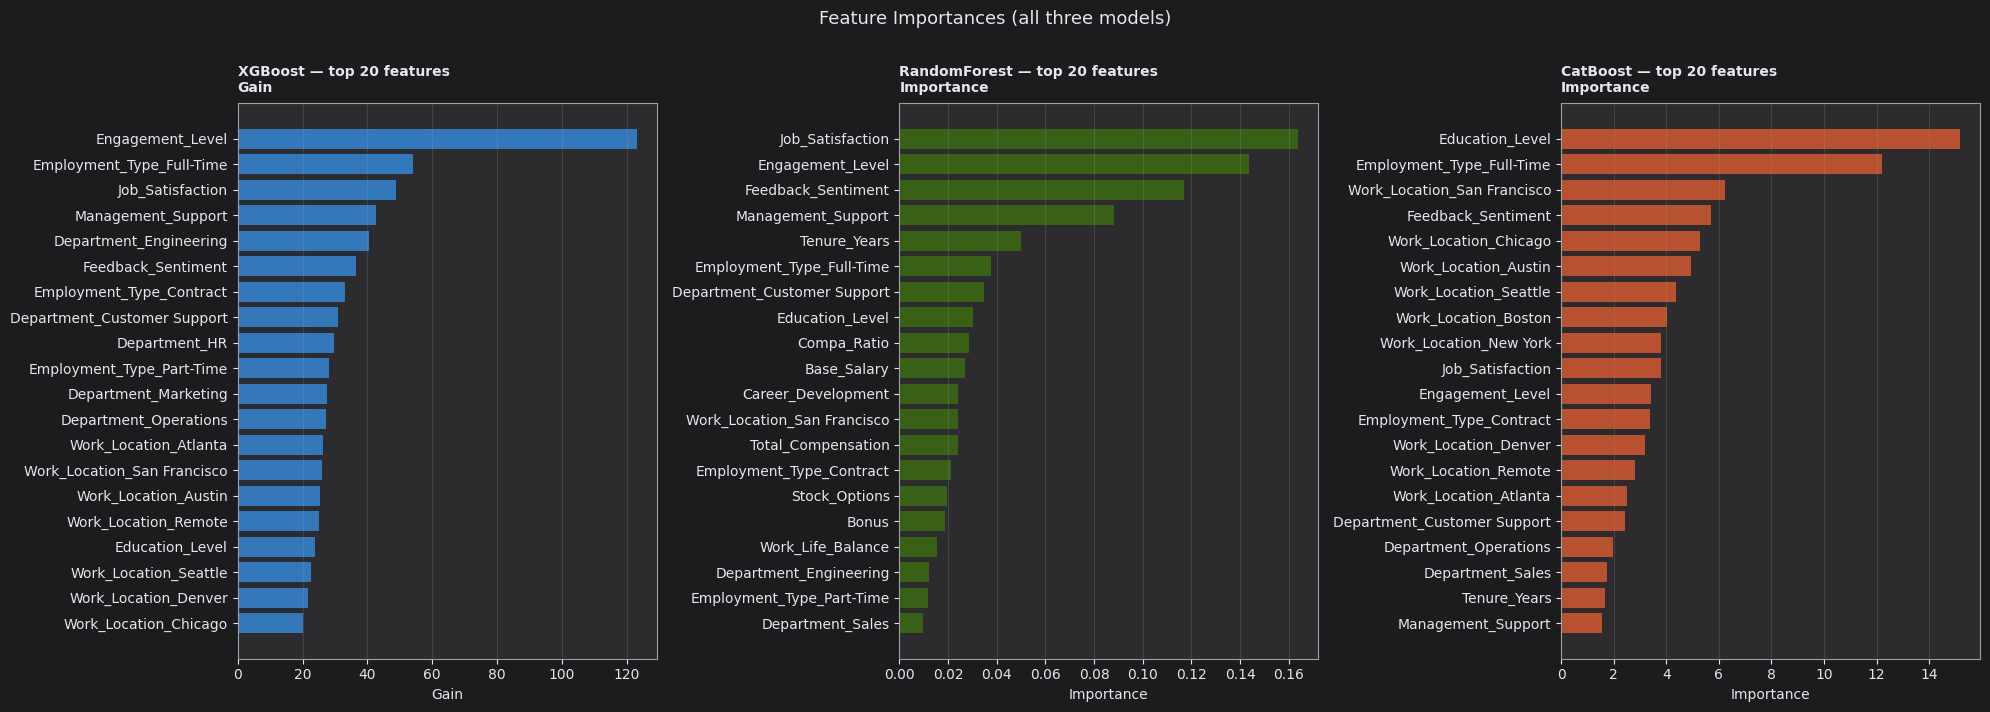

  Saved → outputs/feature_importances.png


In [25]:
print_section("§13  Feature Importances")

TOP_N         = 20
feature_names = X_train_sm.columns.tolist()
colors        = {"XGBoost": "#378ADD", "RandomForest": "#3B6D11", "CatBoost": "#D85A30"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)

for ax, (name, model) in zip(axes, models_dict.items()):
    ax.set_facecolor(CARD_BG); ax.tick_params(colors=TEXT)

    if name == "XGBoost":
        imp = model.get_booster().get_score(importance_type="gain")
        imp_series = pd.Series(imp).reindex(feature_names).fillna(0)
    elif name == "RandomForest":
        imp_series = pd.Series(model.feature_importances_, index=feature_names)
    elif name == "CatBoost":
        imp_series = pd.Series(model.get_feature_importance(), index=feature_names)

    top = imp_series.nlargest(TOP_N).sort_values()
    ax.barh(top.index, top.values, color=colors[name], alpha=0.82)
    styled_title(ax, f"{name} — top {TOP_N} features",
                 "Gain" if name == "XGBoost" else "Importance")
    ax.set_xlabel("Gain" if name == "XGBoost" else "Importance", color=TEXT)
    ax.grid(axis="x", alpha=0.20)

fig.suptitle("Feature Importances (all three models)", color=TEXT, fontsize=13, y=1.01)
plt.tight_layout()
save_fig(fig, "feature_importances")

### 14. Artifact Persistence

**In plain terms:** We save everything needed to reuse or reproduce this work without re-running the full notebook. This includes the trained models (one file each), the best hyperparameter settings, the evaluation scorecard, and — critically — the decision threshold chosen on the validation set. At serving time, a downstream system only needs to load the winner model file and apply that same threshold.

**Technically:** Models are serialised with `joblib` (preferred over `pickle` for scikit-learn / numpy-backed objects — better large-array handling). Hyperparameter dicts are cast to Python-native types before `json.dump` to avoid `np.float32` / `np.int64` serialisation errors. `winner_meta.json` stores `{"winner_model", "threshold", "val_best_f1"}` — the minimum artefact needed for a scoring service to load and call `predict_proba + threshold` correctly (§13, §15).

> **Inputs:** `models_dict`, `best_params_all`, `evaluation_df`, `WINNER_MODEL_NAME`, `WINNER_THRESHOLD`, `winner_row`  
> **Outputs:** [outputs/](outputs/) — one `.joblib` per model, `best_params_all.json`, `model_evaluation.csv`, `winner_meta.json`

In [26]:
print_section("§14  Artifact Persistence")

# ── Save trained model files (.joblib) ────────────────────────────────────────
for name, model in models_dict.items():
    path = OUTPUT_DIR / f"{name.lower()}_best_model.joblib"
    joblib.dump(model, path)
    print(f"  Saved {name:<14} → {path}")

# ── Save hyperparameters as JSON (cast to Python-native types) ────────────────
serialisable = {}
for name, params in best_params_all.items():
    serialisable[name] = {
        k: (float(v) if isinstance(v, (np.floating, float)) else
            int(v)   if isinstance(v, (np.integer, int))   else v)
        for k, v in params.items()
    }
with open(OUTPUT_DIR / "best_params_all.json", "w") as f:
    json.dump(serialisable, f, indent=2)
print(f"  Saved best_params_all.json  → {OUTPUT_DIR}")

# ── Save evaluation scorecard ──────────────────────────────────────────────────
evaluation_df.to_csv(OUTPUT_DIR / "model_evaluation.csv", index=False)
print(f"  Saved model_evaluation.csv  → {OUTPUT_DIR}")

# ── Save winner metadata (threshold needed at inference time) ─────────────────
winner_meta = {
    "winner_model" : WINNER_MODEL_NAME,
    "threshold"    : float(WINNER_THRESHOLD),
    "val_best_f1"  : float(winner_row["val_best_f1"]),
}
with open(OUTPUT_DIR / "winner_meta.json", "w") as f:
    json.dump(winner_meta, f, indent=2)
print(f"  Saved winner_meta.json      → {OUTPUT_DIR}")

print(f"\nAll artefacts written to {OUTPUT_DIR}/")
print(f"Serving file : outputs/{WINNER_MODEL_NAME.lower()}_best_model.joblib")
print(f"Threshold    : {WINNER_THRESHOLD:.4f}  (tuned on validation set)")


────────────────────────────────────────────────────────────
  §14  Artifact Persistence
────────────────────────────────────────────────────────────
  Saved XGBoost        → outputs/xgboost_best_model.joblib
  Saved RandomForest   → outputs/randomforest_best_model.joblib
  Saved CatBoost       → outputs/catboost_best_model.joblib
  Saved best_params_all.json  → outputs
  Saved model_evaluation.csv  → outputs
  Saved winner_meta.json      → outputs

All artefacts written to outputs/
Serving file : outputs/catboost_best_model.joblib
Threshold    : 0.3572  (tuned on validation set)


### 15. Local Explainability — LIME & SHAP

**In plain terms:** Knowing *that* our model predicts someone will leave isn't enough — HR needs to know *why*. This cell picks three representative employees (low, medium, and high risk), then uses two independent explanation methods to show which features pushed the score up or down for each individual. If both methods agree, we can trust the explanation. If they disagree, it's a signal that the local neighbourhood is complex and should be interpreted cautiously.

**Technically:**
- **LIME** (Local Interpretable Model-Agnostic Explanations) fits a sparse linear model in the neighbourhood of each instance, perturbing inputs `num_samples=2000` times and weighting them by proximity. It is model-agnostic but sensitive to neighbourhood sample size.
- **SHAP** (SHapley Additive exPlanations) uses `TreeExplainer`, which computes exact Shapley values in $O(TLD^2)$ time (T=trees, L=leaves, D=depth) — no sampling noise. The SHAP values for the positive class (`shap_values[1]` or the 2-D array directly) represent contribution toward $P(Y{=}1)$.
- **Agreement metric:** For each feature matched between LIME and SHAP, we compare *sign* (both push toward attrition or both push away). Concordance ≥ 70% is considered meaningful local stability (§20).

> **Inputs:** `WINNER_MODEL`, `X_train`, `X_test`, `y_test`  
> **Outputs:** Three per-employee LIME+SHAP comparison figures saved to [outputs/](outputs/), plus printed concordance summary


────────────────────────────────────────────────────────────
  §15  Local Explainability — LIME & SHAP
────────────────────────────────────────────────────────────


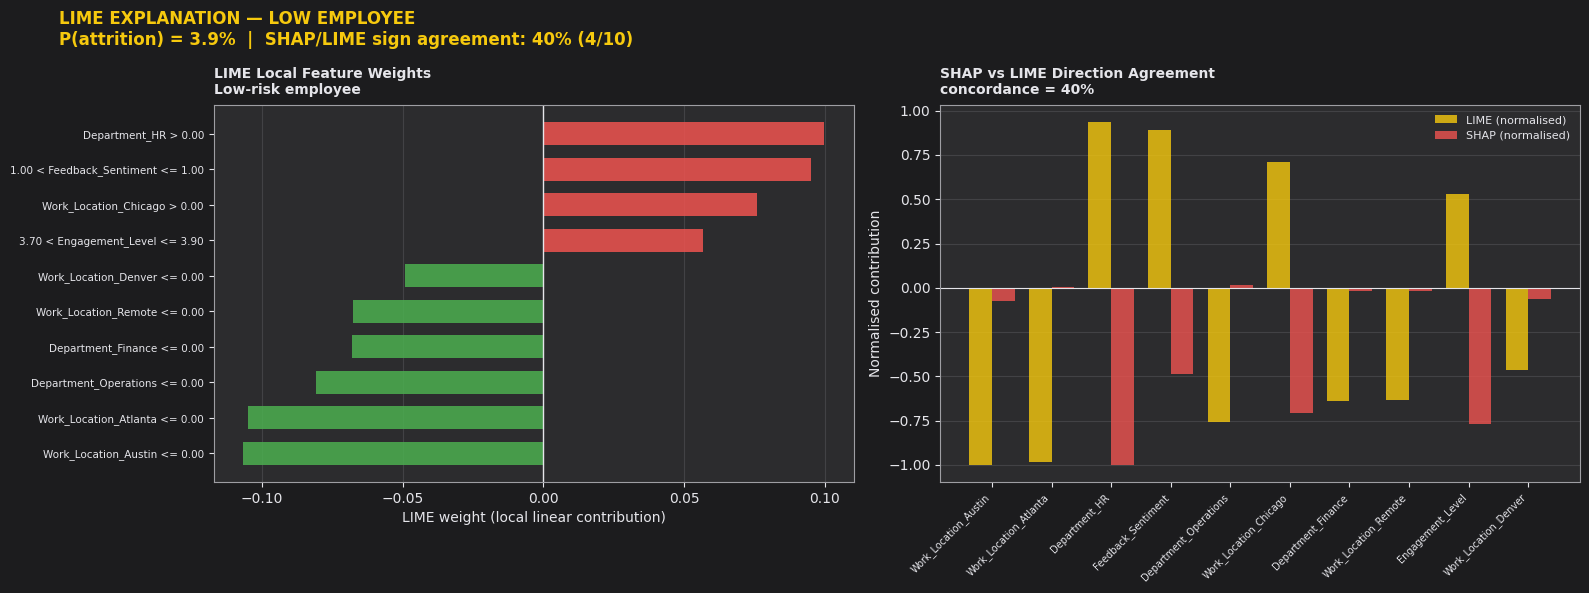

  Saved → outputs/lime_shap_low.png

Low Employee  (P(attrition) = 3.9%  |  SHAP/LIME agreement = 40%)
  Feature Rule                              LIME Weight
  ──────────────────────────────────────────────────────
  Work_Location_Austin <= 0.00                -0.1069  [↓ risk]
  Work_Location_Atlanta <= 0.00               -0.1052  [↓ risk]
  Department_HR > 0.00                        +0.0999  [↑ risk]
  1.00 < Feedback_Sentiment <= 1.00           +0.0950  [↑ risk]
  Department_Operations <= 0.00               -0.0809  [↓ risk]
  Work_Location_Chicago > 0.00                +0.0758  [↑ risk]
  Department_Finance <= 0.00                  -0.0682  [↓ risk]
  Work_Location_Remote <= 0.00                -0.0678  [↓ risk]
  3.70 < Engagement_Level <= 3.90             +0.0566  [↑ risk]
  Work_Location_Denver <= 0.00                -0.0493  [↓ risk]


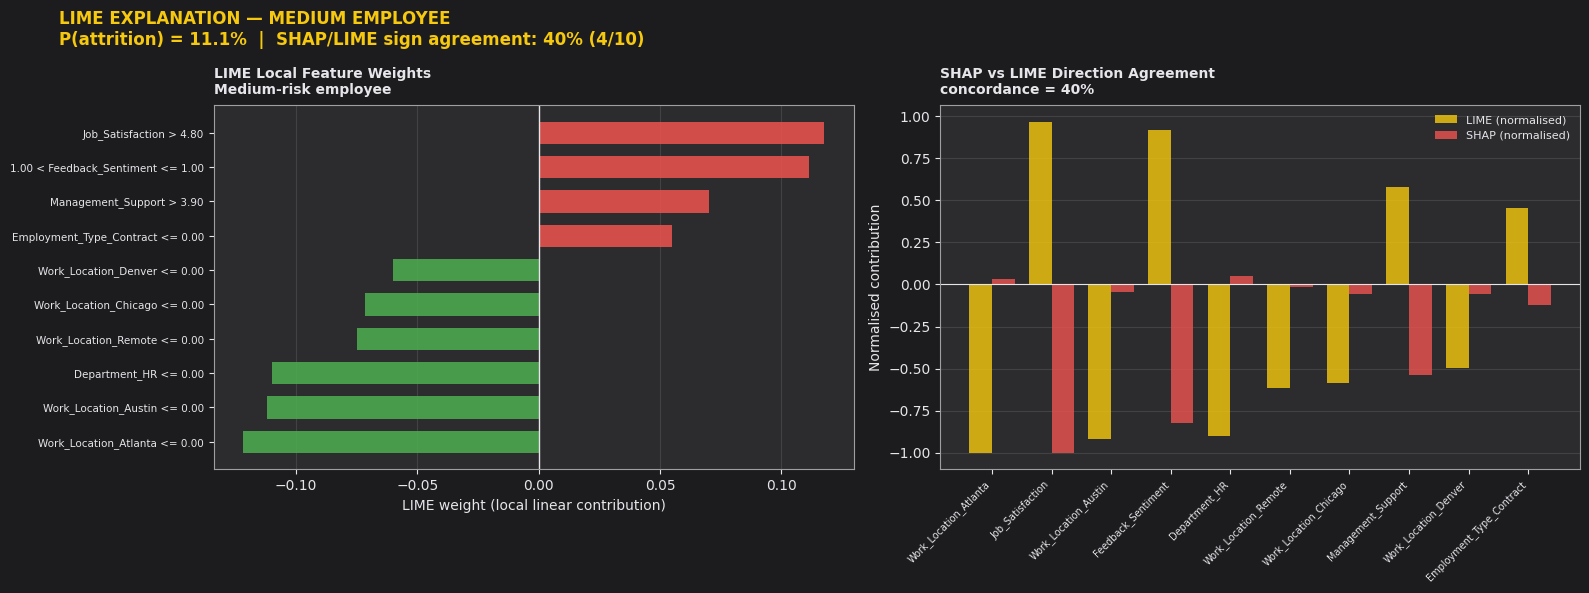

  Saved → outputs/lime_shap_medium.png

Medium Employee  (P(attrition) = 11.1%  |  SHAP/LIME agreement = 40%)
  Feature Rule                              LIME Weight
  ──────────────────────────────────────────────────────
  Work_Location_Atlanta <= 0.00               -0.1218  [↓ risk]
  Job_Satisfaction > 4.80                     +0.1178  [↑ risk]
  Work_Location_Austin <= 0.00                -0.1118  [↓ risk]
  1.00 < Feedback_Sentiment <= 1.00           +0.1115  [↑ risk]
  Department_HR <= 0.00                       -0.1099  [↓ risk]
  Work_Location_Remote <= 0.00                -0.0746  [↓ risk]
  Work_Location_Chicago <= 0.00               -0.0715  [↓ risk]
  Management_Support > 3.90                   +0.0702  [↑ risk]
  Work_Location_Denver <= 0.00                -0.0601  [↓ risk]
  Employment_Type_Contract <= 0.00            +0.0550  [↑ risk]


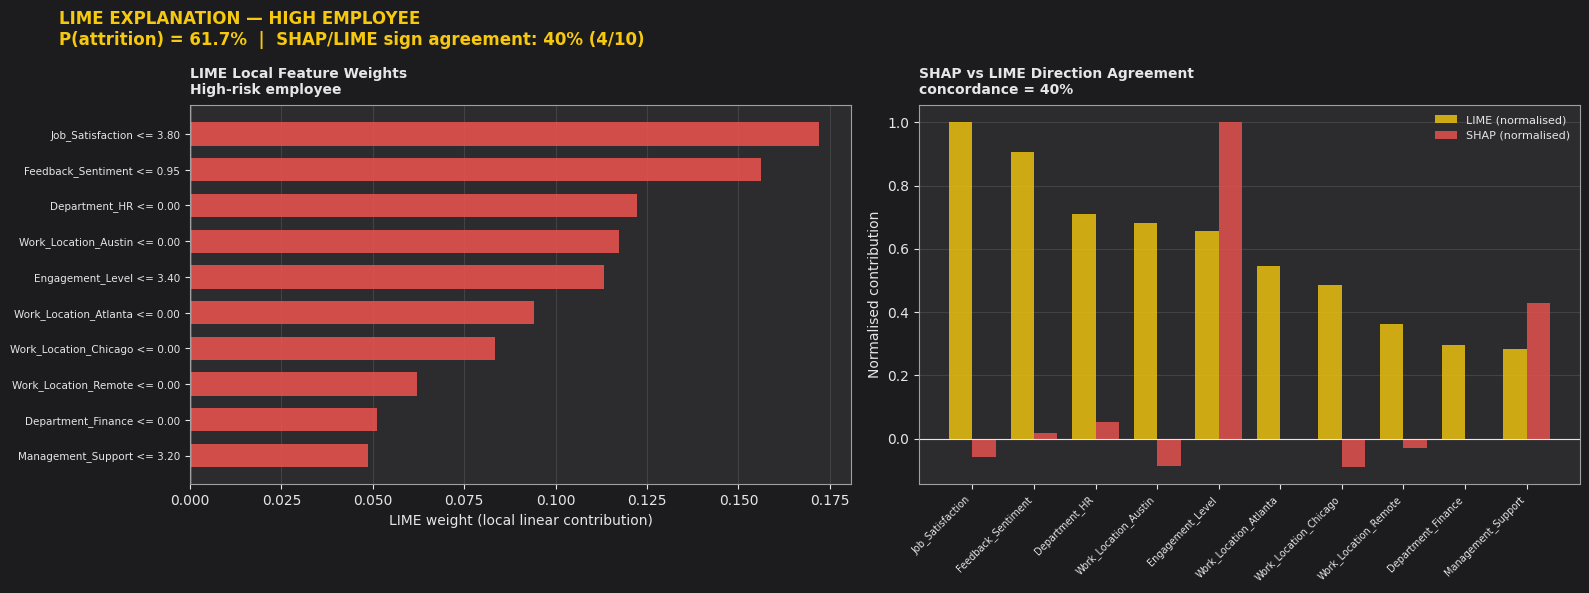

  Saved → outputs/lime_shap_high.png

High Employee  (P(attrition) = 61.7%  |  SHAP/LIME agreement = 40%)
  Feature Rule                              LIME Weight
  ──────────────────────────────────────────────────────
  Job_Satisfaction <= 3.80                    +0.1722  [↑ risk]
  Feedback_Sentiment <= 0.95                  +0.1563  [↑ risk]
  Department_HR <= 0.00                       +0.1223  [↑ risk]
  Work_Location_Austin <= 0.00                +0.1175  [↑ risk]
  Engagement_Level <= 3.40                    +0.1132  [↑ risk]
  Work_Location_Atlanta <= 0.00               +0.0941  [↑ risk]
  Work_Location_Chicago <= 0.00               +0.0835  [↑ risk]
  Work_Location_Remote <= 0.00                +0.0622  [↑ risk]
  Department_Finance <= 0.00                  +0.0511  [↑ risk]
  Management_Support <= 3.20                  +0.0487  [↑ risk]


In [27]:
print_section("§15  Local Explainability — LIME & SHAP")

# ── Compute winner model scores on test set ────────────────────────────────────
test_probs = WINNER_MODEL.predict_proba(X_test)[:, 1]

# ── Select three representative employees (low / median / high risk) ──────────
sorted_idx = np.argsort(test_probs)
sample_cases = {
    "Low"    : int(sorted_idx[int(0.10 * len(sorted_idx))]),
    "Medium" : int(sorted_idx[int(0.50 * len(sorted_idx))]),
    "High"   : int(sorted_idx[int(0.90 * len(sorted_idx))]),
}

# ── Build LIME explainer on training data ─────────────────────────────────────
from lime.lime_tabular import LimeTabularExplainer

lime_exp = LimeTabularExplainer(
    training_data = np.array(X_train),
    feature_names = X_train.columns.tolist(),
    class_names   = ["Stayed", "Left"],
    mode          = "classification",
    random_state  = RANDOM_STATE,
)

# ── Compute SHAP values using TreeExplainer (exact, no sampling noise) ────────
shap_arr = None
try:
    import shap
    explainer   = shap.TreeExplainer(WINNER_MODEL)
    shap_values = explainer.shap_values(X_test)
    # shap_values is a 2-D array (positive class) for XGBoost/CatBoost;
    # for RF it may be a list [class_0, class_1]
    shap_arr = shap_values[1] if isinstance(shap_values, list) else shap_values
except Exception as exc:
    print(f"SHAP unavailable ({exc}) — skipping concordance panel")

# ── Per-employee explanation loop ─────────────────────────────────────────────
for label, idx in sample_cases.items():
    prob = test_probs[idx]

    # LIME: fit local linear model
    exp = lime_exp.explain_instance(
        X_test.iloc[idx].values,
        WINNER_MODEL.predict_proba,
        num_features = 10,
        num_samples  = 2000,
        top_labels   = 1,
    )
    available_label = list(exp.local_exp.keys())[0]
    lime_list    = exp.as_list(label=available_label)
    lime_rules   = [r for r, _ in lime_list]
    lime_weights = [w for _, w in lime_list]

    # SHAP: per-instance values for matched features
    shap_dict = {}
    if shap_arr is not None:
        sv = shap_arr[idx]
        shap_dict = {X_test.columns[i]: sv[i] for i in range(len(sv))}

    # Sign-concordance between LIME and SHAP
    agree, disagree = 0, 0
    for rule, lw in lime_list:
        for feat_name in X_test.columns:
            if feat_name in rule:
                sw = shap_dict.get(feat_name, 0)
                if (lw > 0) == (sw > 0):
                    agree += 1
                else:
                    disagree += 1
                break
    total_matched  = agree + disagree
    agreement_pct  = agree / total_matched if total_matched > 0 else float("nan")

    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
    fig.suptitle(
        f"LIME EXPLANATION — {label.upper()} EMPLOYEE\n"
        f"P(attrition) = {prob:.1%}  |  SHAP/LIME sign agreement: {agreement_pct:.0%} "
        f"({agree}/{total_matched})",
        color=ACCENT, fontsize=12, fontweight="bold", x=0.04, ha="left",
    )

    # Left: LIME bar chart
    ax = axes[0]
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors=TEXT)
    sorted_pairs = sorted(zip(lime_weights, lime_rules))
    lw_s, lr_s   = zip(*sorted_pairs)
    bar_colors   = [LEAVE_COLOR if w > 0 else STAY_COLOR for w in lw_s]
    ax.barh(range(len(lr_s)), lw_s, color=bar_colors, alpha=0.85, height=0.65)
    ax.set_yticks(range(len(lr_s)))
    ax.set_yticklabels(lr_s, fontsize=7.5, color=TEXT)
    ax.axvline(0, color=TEXT, lw=1)
    ax.set_xlabel("LIME weight (local linear contribution)", color=TEXT)
    styled_title(ax, "LIME Local Feature Weights", f"{label}-risk employee")
    ax.xaxis.grid(True, alpha=0.20); ax.set_axisbelow(True)

    # Right: SHAP vs LIME normalized comparison
    ax = axes[1]
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors=TEXT)

    comparison_rows = []
    for rule, lw in lime_list:
        for fname in X_test.columns:
            if fname in rule:
                sw = shap_dict.get(fname, 0)
                comparison_rows.append({"feature": fname, "LIME": lw, "SHAP": sw})
                break

    if comparison_rows:
        comp_df      = pd.DataFrame(comparison_rows).set_index("feature")
        comp_df_norm = comp_df / (comp_df.abs().max() + 1e-9)
        x, w         = np.arange(len(comp_df_norm)), 0.38
        ax.bar(x - w/2, comp_df_norm["LIME"], w, color=ACCENT,       alpha=0.80, label="LIME (normalised)")
        ax.bar(x + w/2, comp_df_norm["SHAP"], w, color=LEAVE_COLOR,  alpha=0.80, label="SHAP (normalised)")
        ax.set_xticks(x)
        ax.set_xticklabels(comp_df_norm.index, rotation=45, ha="right", fontsize=7, color=TEXT)
        ax.axhline(0, color=TEXT, lw=0.8)
        ax.set_ylabel("Normalised contribution", color=TEXT)
        styled_title(ax, "SHAP vs LIME Direction Agreement", f"concordance = {agreement_pct:.0%}")
        ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=8)
        ax.yaxis.grid(True, alpha=0.20); ax.set_axisbelow(True)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "SHAP values unavailable", ha="center", va="center",
                transform=ax.transAxes, color=NEUTRAL, fontsize=10)

    plt.tight_layout()
    save_fig(fig, f"lime_shap_{label.lower()}")

    # Textual summary
    print(f"\n{label} Employee  (P(attrition) = {prob:.1%}  |  SHAP/LIME agreement = {agreement_pct:.0%})")
    print(f"  {'Feature Rule':<40} {'LIME Weight':>12}")
    print("  " + "─" * 54)
    for rule, weight in lime_list:
        direction = "↑ risk" if weight > 0 else "↓ risk"
        print(f"  {rule:<40} {weight:>+10.4f}  [{direction}]")


────────────────────────────────────────────────────────────
  §16  Risk Scoring & Employee Segmentation
────────────────────────────────────────────────────────────

  Total employees scored : 10,000
  High     :   846  (8.5%)
  Medium   : 1,273  (12.7%)
  Low      : 7,881  (78.8%)


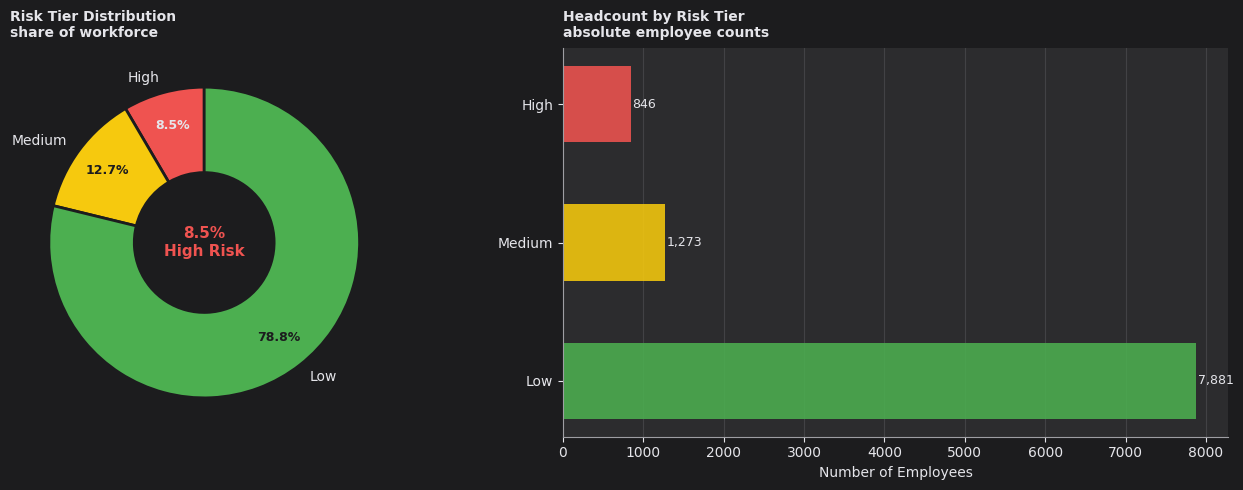

  Saved → outputs/risk_tier_distribution.png

────────────────────────────────────────────────────────────
  16.2  SHAP-driven cluster features
────────────────────────────────────────────────────────────
   1. Job_Satisfaction                     mean|SHAP|=0.49307
   2. Engagement_Level                     mean|SHAP|=0.40973
   3. Feedback_Sentiment                   mean|SHAP|=0.31348
   4. Education_Level                      mean|SHAP|=0.24304
   5. Management_Support                   mean|SHAP|=0.22194
   6. Employment_Type_Full-Time            mean|SHAP|=0.21594
   7. Tenure_Years                         mean|SHAP|=0.20028
   8. Work_Location_San Francisco          mean|SHAP|=0.12753
   9. Work_Location_Chicago                mean|SHAP|=0.09302
  10. Employment_Type_Contract             mean|SHAP|=0.08797
  11. Department_Customer Support          mean|SHAP|=0.08742
  12. Work_Location_Austin                 mean|SHAP|=0.08375
  13. Department_HR                        mean|SHA

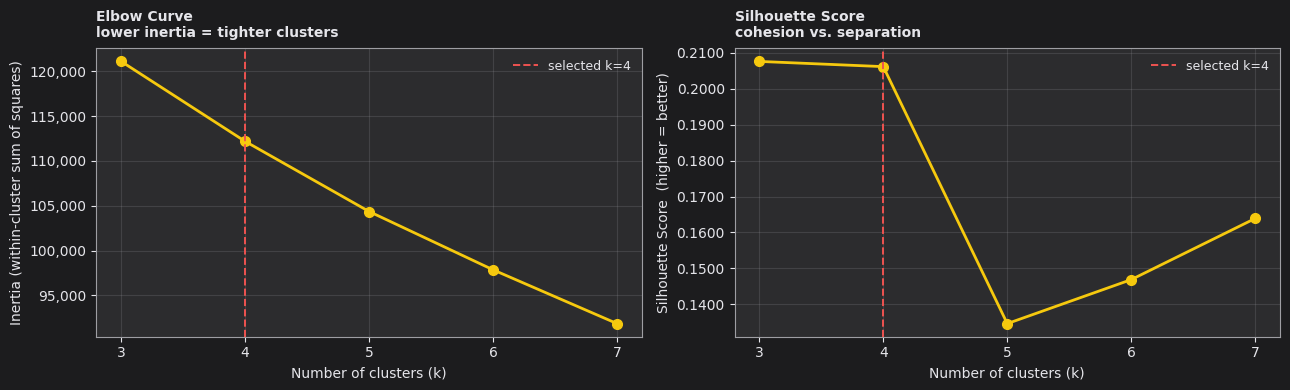

  Saved → outputs/cluster_elbow.png

  Selected k = 4


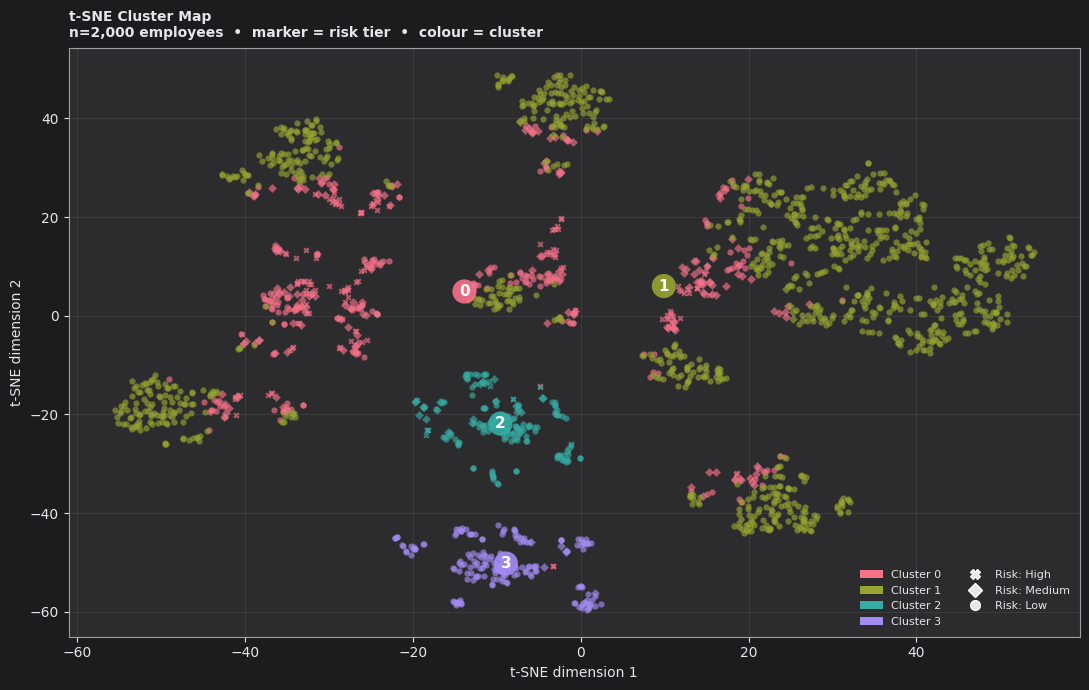

  Saved → outputs/cluster_tsne.png

────────────────────────────────────────────────────────────
  16.5  Persona score matrix (z-score alignment)
────────────────────────────────────────────────────────────
   Cluster  Disengaged Mid-Ten  Burnt-Out Overachi  Underpaid High Per  Stable Performer  
  C0 → Disengaged Mid-Tenure                   +1.118              +0.080              +0.057              -1.235
  C1 → Stable Performer                        -0.517              -0.220              -0.081              +0.549
  C2 → Burnt-Out Overachiever                  +0.261              +1.356              -0.066              -0.234
  C3 → Underpaid High Performer                -0.193              -0.268              +0.520              +0.314

────────────────────────────────────────────────────────────
  16.5  Cluster Persona Summary
────────────────────────────────────────────────────────────


,cluster,cluster_persona,headcount,avg_attrition_prob,pct_high_risk,primary_driver
0,0,Disengaged Mid-Tenure,2574,0.495,28.3%,Job_Satisfaction
1,2,Burnt-Out Overachiever,929,0.285,11.6%,Employment_Type_Contract
2,3,Underpaid High Performer,737,0.104,1.2%,Department_HR
3,1,Stable Performer,5760,0.097,0.0%,Job_Satisfaction


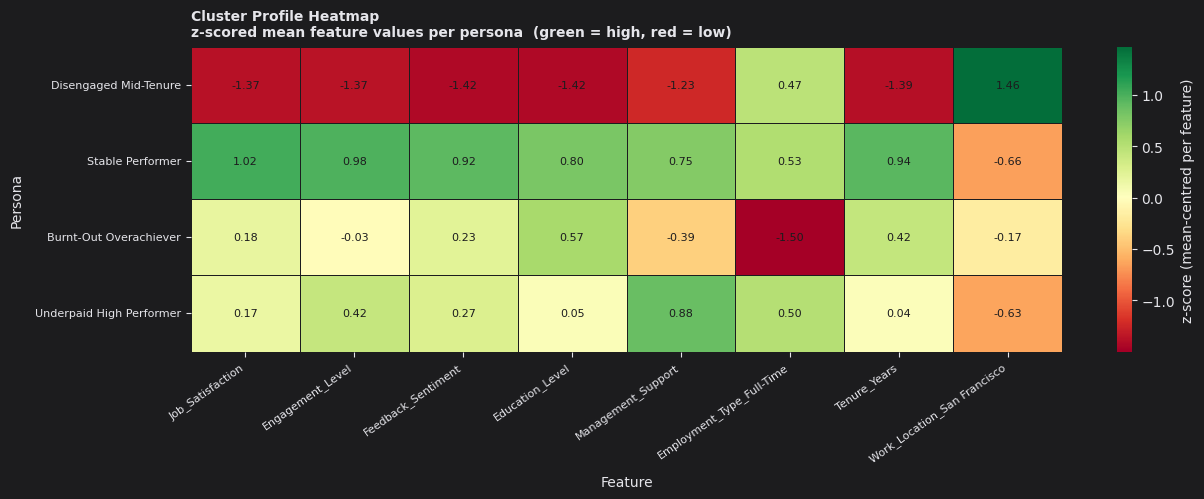

  Saved → outputs/cluster_profiles.png


In [30]:
print_section("§16  Risk Scoring & Employee Segmentation")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ═══════════════════════════════════════════════════════════════════════════════
# 16.1  Full-Workforce Risk Scoring
# ═══════════════════════════════════════════════════════════════════════════════

def assign_risk_tier(p: float) -> str:
    """Map attrition probability to a categorical risk tier.

    Thresholds H>=0.65 / M>=0.35 are slightly more sensitive than classic
    0.70/0.40 to surface the early-warning Medium cohort cost-effectively.
    """
    if p >= 0.65:
        return "High"
    if p >= 0.35:
        return "Medium"
    return "Low"

all_probs = WINNER_MODEL.predict_proba(X)[:, 1]

scored_df = pd.DataFrame({
    "employee_idx"         : X.index,
    "attrition_probability": all_probs,
    "risk_tier"            : pd.Categorical(
        [assign_risk_tier(p) for p in all_probs],
        categories=["High", "Medium", "Low"],
        ordered=True,
    ),
}, index=X.index)

tier_counts = scored_df["risk_tier"].value_counts().reindex(["High", "Medium", "Low"])
tier_colors = [LEAVE_COLOR, ACCENT, STAY_COLOR]

print(f"\n  Total employees scored : {len(scored_df):,}")
for tier, cnt in tier_counts.items():
    print(f"  {tier:<8} : {cnt:>5,}  ({cnt/len(scored_df):.1%})")

# ── Risk tier distribution — donut + horizontal bar ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# Left: Donut
ax = axes[0]
ax.set_facecolor(BG)
wedges, _, autotexts = ax.pie(
    tier_counts, labels=tier_counts.index,
    autopct="%1.1f%%", startangle=90,
    colors=tier_colors, pctdistance=0.78,
    wedgeprops={"width": 0.55, "edgecolor": BG, "linewidth": 2},
)
for wt in autotexts:
    wt.set(color=BG, fontsize=9, fontweight="bold")
for lbl in ax.texts[:3]:
    lbl.set_color(TEXT)
ax.text(0, 0, f"{tier_counts['High']/len(scored_df)*100:.1f}%\nHigh Risk",
        ha="center", va="center", fontsize=11, color=LEAVE_COLOR, fontweight="bold")
styled_title(ax, "Risk Tier Distribution", "share of workforce")

# Right: Horizontal bar
ax = axes[1]
ax.set_facecolor(CARD_BG)
ax.tick_params(colors=TEXT)
bars = ax.barh(tier_counts.index[::-1], tier_counts.values[::-1],
               color=tier_colors[::-1], alpha=0.88, height=0.55)
for bar, cnt in zip(bars, tier_counts.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", color=TEXT, fontsize=9)
ax.set_xlabel("Number of Employees", color=TEXT)
ax.xaxis.grid(True, alpha=0.20)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
styled_title(ax, "Headcount by Risk Tier", "absolute employee counts")

plt.tight_layout()
save_fig(fig, "risk_tier_distribution")

# ═══════════════════════════════════════════════════════════════════════════════
# 16.2  SHAP-Driven Feature Selection for Clustering
# ═══════════════════════════════════════════════════════════════════════════════
N_CLUSTER_FEATS   = 15
mean_abs_shap_ser = pd.Series(np.abs(shap_arr).mean(axis=0), index=X_test.columns)
top_cluster_feats = mean_abs_shap_ser.nlargest(N_CLUSTER_FEATS).index.tolist()

print_section("16.2  SHAP-driven cluster features")
for i, f in enumerate(top_cluster_feats, 1):
    print(f"  {i:>2}. {f:<35}  mean|SHAP|={mean_abs_shap_ser[f]:.5f}")

# Build cluster input: top-15 SHAP features + predicted probability
cluster_input = X[top_cluster_feats].copy().astype(float)
cluster_input["attrition_probability"] = all_probs

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_input)

# ═══════════════════════════════════════════════════════════════════════════════
# 16.3  K-Means — Elbow + Silhouette for Optimal k
# ═══════════════════════════════════════════════════════════════════════════════
ks         = list(range(3, 8))
inertias   = []
sil_scores = []

for k in ks:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(
        silhouette_score(cluster_scaled, labels, sample_size=3000, random_state=RANDOM_STATE)
    )

best_k = ks[int(np.argmax(sil_scores))]
best_k = max(best_k, 4)          # guarantee at least 4 clusters for persona breadth

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG)

metric_sets = [
    (inertias,   "Inertia (within-cluster sum of squares)", ",.0f"),
    (sil_scores, "Silhouette Score  (higher = better)",     ".4f"),
]
for ax, (vals, ylabel, fmt) in zip(axes, metric_sets):
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors=TEXT)
    ax.plot(ks, vals, marker="o", color=ACCENT, linewidth=2, markersize=7)
    ax.axvline(best_k, color=LEAVE_COLOR, linestyle="--", linewidth=1.4,
               label=f"selected k={best_k}")
    ax.set_xlabel("Number of clusters (k)", color=TEXT)
    ax.set_ylabel(ylabel, color=TEXT)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _, f=fmt: format(v, f)))
    ax.legend(facecolor=CARD_BG, edgecolor="none", labelcolor=TEXT, fontsize=9)
    ax.xaxis.grid(True, alpha=0.20)
    ax.yaxis.grid(True, alpha=0.20)
    ax.set_axisbelow(True)

styled_title(axes[0], "Elbow Curve",       "lower inertia = tighter clusters")
styled_title(axes[1], "Silhouette Score",  "cohesion vs. separation")
plt.tight_layout()
save_fig(fig, "cluster_elbow")
print(f"\n  Selected k = {best_k}")

# Final KMeans fit
cluster_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
clusters      = cluster_model.fit_predict(cluster_scaled)
scored_df["cluster"] = clusters

# ═══════════════════════════════════════════════════════════════════════════════
# 16.4  t-SNE Visualisation (subsample 2,000 for speed)
# ═══════════════════════════════════════════════════════════════════════════════
TSNE_N   = 2_000
rng      = np.random.default_rng(RANDOM_STATE)
tsne_idx = rng.choice(len(cluster_scaled), size=min(TSNE_N, len(cluster_scaled)), replace=False)

tsne_scaled = cluster_scaled[tsne_idx]
tsne_tiers  = scored_df["risk_tier"].values[tsne_idx]
tsne_clusts = clusters[tsne_idx]

tsne    = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca",
               learning_rate="auto", perplexity=30)
tsne_xy = tsne.fit_transform(tsne_scaled)

tsne_plot_df = pd.DataFrame({
    "x"      : tsne_xy[:, 0],
    "y"      : tsne_xy[:, 1],
    "cluster": tsne_clusts,
    "tier"   : tsne_tiers,
})

cluster_palette = sns.color_palette("husl", best_k)
tier_markers    = {"High": "X", "Medium": "D", "Low": "o"}

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.set_facecolor(CARD_BG)
ax.tick_params(colors=TEXT)

for c_idx in range(best_k):
    c_mask = tsne_plot_df["cluster"] == c_idx
    for tier, marker in tier_markers.items():
        sub = tsne_plot_df[c_mask & (tsne_plot_df["tier"] == tier)]
        if len(sub):
            ax.scatter(sub["x"], sub["y"],
                       c=[cluster_palette[c_idx]], marker=marker,
                       s=20, alpha=0.65, linewidths=0)

# Annotate cluster centroids
for c_idx in range(best_k):
    c_mask  = tsne_plot_df["cluster"] == c_idx
    cx, cy  = tsne_plot_df.loc[c_mask, "x"].mean(), tsne_plot_df.loc[c_mask, "y"].mean()
    ax.text(cx, cy, str(c_idx), ha="center", va="center",
            fontsize=11, fontweight="bold", color="white",
            bbox={"boxstyle": "circle,pad=0.3", "fc": cluster_palette[c_idx], "ec": "none", "alpha": 0.9})

cluster_legend = [Patch(fc=cluster_palette[c], label=f"Cluster {c}") for c in range(best_k)]
tier_legend    = [
    Line2D([0], [0], marker=m, color="w", markerfacecolor=TEXT,
           markersize=7, linestyle="None", label=f"Risk: {t}")
    for t, m in tier_markers.items()
]
ax.legend(handles=cluster_legend + tier_legend,
          loc="lower right", facecolor=CARD_BG, edgecolor="none",
          labelcolor=TEXT, fontsize=8, ncol=2)
ax.set_xlabel("t-SNE dimension 1", color=TEXT)
ax.set_ylabel("t-SNE dimension 2", color=TEXT)
ax.xaxis.grid(True, alpha=0.15)
ax.yaxis.grid(True, alpha=0.15)
styled_title(ax, "t-SNE Cluster Map",
             f"n={TSNE_N:,} employees  •  marker = risk tier  •  colour = cluster")
plt.tight_layout()
save_fig(fig, "cluster_tsne")

# ═══════════════════════════════════════════════════════════════════════════════
# 16.5  Persona Naming & Profile Table
# ═══════════════════════════════════════════════════════════════════════════════
# cluster_model.cluster_centers_ is already in StandardScaler z-score space —
# features are directly comparable without raw-scale dominance issues.
all_cluster_cols = top_cluster_feats + ["attrition_probability"]
centers_df       = pd.DataFrame(cluster_model.cluster_centers_, columns=all_cluster_cols)

# The feature with the highest absolute z-score deviation identifies each
# cluster's most distinctive behavioural characteristic.
dominant_driver = centers_df[top_cluster_feats].abs().idxmax(axis=1).to_dict()

# ── Directional z-score profiles ─────────────────────────────────────────────
# Each entry maps feature names (substring match against top_cluster_feats) to
# a signed weight (+1 = expect high z, -1 = expect low z).  The persona score
# for a cluster is the mean of (weight × cluster_center_z) across matched features.
_PERSONA_PROFILES: Dict[str, Dict[str, float]] = {
    "Disengaged Mid-Tenure": {          # expect low engagement + satisfaction + high risk
        "satisfaction"        : -1.0,
        "engagement"          : -1.0,
        "feedback"            : -1.0,
        "management"          : -1.0,
        "career"              : -1.0,
        "attrition_probability": +2.0,  # strong weight on high-risk signal
    },
    "Burnt-Out Overachiever": {         # expect contract employment + moderate attrition
        "contract"            : +1.0,
        "full"                : -1.0,   # NOT full-time → contract / part-time
        "tenure"              : +1.0,   # longer service
        "attrition_probability": +1.0,
    },
    "Underpaid High Performer": {       # expect high education / career dev, dept-specific
        "education"           : +1.0,
        "career"              : +1.0,
        "department"          : +1.0,
        "satisfaction"        : -0.5,   # somewhat dissatisfied despite credentials
    },
    "Stable Performer": {               # expect high satisfaction and very low risk
        "satisfaction"        : +1.0,
        "engagement"          : +1.0,
        "feedback"            : +1.0,
        "management"          : +1.0,
        "attrition_probability": -2.0,  # strong weight on low-risk signal
    },
}

def _profile_score(cluster_id: int, profile: Dict[str, float]) -> float:
    """Signed alignment between a cluster's z-score center and a persona profile.

    For each keyword in the profile, we find matching features in
    top_cluster_feats (+ attrition_probability) and compute the weighted mean
    of the cluster center's z-scores.  A high positive score means the cluster
    closely matches the persona's expected behavioural signature.
    """
    terms = []
    all_cols = top_cluster_feats + ["attrition_probability"]
    for keyword, weight in profile.items():
        matched = [c for c in all_cols if keyword in c.lower()]
        for feat in matched:
            terms.append(weight * float(centers_df.iloc[cluster_id][feat]))
    return float(np.mean(terms)) if terms else 0.0

# Build full score matrix: cluster × persona
persona_names = list(_PERSONA_PROFILES.keys())
score_matrix  = {
    (c, p): _profile_score(c, _PERSONA_PROFILES[p])
    for c in range(best_k)
    for p in persona_names
}

# Greedy unique assignment — highest-scoring (cluster, persona) pairs first
sorted_pairs  = sorted(score_matrix.items(), key=lambda x: x[1], reverse=True)
persona_map   : Dict[int, str] = {}
used_personas : set             = set()

for (c, persona), score in sorted_pairs:
    if c in persona_map or persona in used_personas:
        continue
    persona_map[c] = persona
    used_personas.add(persona)

# Handle extra clusters when best_k > 4
for c in range(best_k):
    if c not in persona_map:
        persona_map[c] = f"Emerging Profile {c}"

print_section("16.5  Persona score matrix (z-score alignment)")
header = f"  {'Cluster':>8}  " + "  ".join(f"{p[:18]:<18}" for p in persona_names)
print(header)
for c in range(best_k):
    row_scores = "  ".join(f"{score_matrix[(c, p)]:>+18.3f}" for p in persona_names)
    assigned   = persona_map[c]
    print(f"  C{c} → {assigned:<26}  {row_scores}")

scored_df["cluster_persona"] = scored_df["cluster"].map(persona_map)

persona_table = (
    scored_df.groupby(["cluster", "cluster_persona"])
    .agg(
        headcount          =("attrition_probability", "count"),
        avg_attrition_prob =("attrition_probability", "mean"),
        pct_high_risk      =("risk_tier", lambda s: (s == "High").mean()),
    )
    .reset_index()
    .assign(primary_driver=lambda d: d["cluster"].map(dominant_driver))
    .sort_values("avg_attrition_prob", ascending=False)
    .reset_index(drop=True)
)

print_section("16.5  Cluster Persona Summary")
display(
    persona_table.style
    .format({"avg_attrition_prob": "{:.3f}", "pct_high_risk": "{:.1%}"})
    .background_gradient(subset=["avg_attrition_prob", "pct_high_risk"], cmap="Oranges")
    .set_caption("Cluster personas — sorted by average attrition probability")
)

# ── Cluster profile heatmap (persona × top-8 SHAP features, z-scored means) ──
TOP_HEAT      = 8
heat_features = top_cluster_feats[:TOP_HEAT]
heat_df       = (
    cluster_input.assign(cluster=clusters)
    .groupby("cluster")[heat_features]
    .mean()
    .assign(persona=lambda d: d.index.map(persona_map))
    .set_index("persona")
)
# Z-score across personas so each feature column is on a comparable scale
heat_norm = (heat_df - heat_df.mean()) / (heat_df.std() + 1e-9)

fig, ax = plt.subplots(
    figsize=(13, max(3.5, len(heat_norm) * 0.9 + 1.5)), facecolor=BG
)
ax.set_facecolor(CARD_BG)
sns.heatmap(
    heat_norm, ax=ax, cmap="RdYlGn", center=0,
    linewidths=0.5, linecolor=BG,
    annot=True, fmt=".2f",
    cbar_kws={"label": "z-score (mean-centred per feature)"},
    annot_kws={"size": 8, "color": BG},
)
ax.tick_params(colors=TEXT, labelsize=8)
ax.set_xlabel("Feature", color=TEXT, labelpad=8)
ax.set_ylabel("Persona", color=TEXT, labelpad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
styled_title(ax, "Cluster Profile Heatmap",
             "z-scored mean feature values per persona  (green = high, red = low)")
plt.tight_layout()
save_fig(fig, "cluster_profiles")


### 17. Retention Strategy Recommendations

**In plain terms:** Knowing who is at risk is only half the job — HR needs to know *what to do about it*. This cell translates the persona segmentation into a concrete action matrix: each archetype gets a named root cause and a specific recommended intervention. We then layer on financial context by estimating the expected cost of each departure (1.5× annual salary is the industry standard replacement cost estimate), so the team can prioritise by business impact rather than just probability alone. The cell ends by identifying the ten individual employees who represent the highest dollar risk to the organisation.

**Technically:**
- **Intervention matrix:** Hardcoded for the four archetypes. This is intentional — prescriptive HR interventions should be reviewed by a domain expert and not auto-generated. The matrix is the output artifact that gets handed to HR leadership.
- **Expected attrition cost:** $E[\text{cost}_i] = P(\text{attrition}_i) \times 1.5 \times \text{Base\_Salary}_i$. The `Base_Salary` is read directly from `model_df` (it was kept in the feature matrix after the protected-attribute isolation step). The 1.5× multiplier is a widely-cited industry estimate covering recruiting, onboarding, and productivity ramp-up.
- **Priority tier logic:** High priority if `avg_attrition_prob ≥ 0.65` (same threshold as risk tier), Medium if ≥ 0.35, Low otherwise. This makes priority fully consistent with the individual risk scores in §16.
- **Top-10 list:** Sorted by `expected_attrition_cost` descending — this surfaces the employees whose departure would be most costly, not simply the most likely to leave. A 95% probability on a junior role may rank below a 55% probability on a senior engineer.

> **Inputs:** `persona_table`, `scored_df`, `model_df`  
> **Outputs:** `retention_strategy_matrix` — figures to [outputs/](outputs/), CSVs to [outputs/](outputs/)



────────────────────────────────────────────────────────────
  §17  Retention Strategy Recommendations
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  17.1  Intervention Matrix
────────────────────────────────────────────────────────────


Persona,Headcount,Avg Attrition Prob,% High Risk,Primary Driver,Recommended Action,Priority,Est. ROI Impact
Disengaged Mid-Tenure,2574,0.495000,28.3%,Engagement & growth deficit,Career pathing conversation + manager coaching + stretch assignments,Medium,Moderate
Burnt-Out Overachiever,929,0.285000,11.6%,Workload & burnout pressure,Wellness programme + workload rebalance + flexible working pilot,Low,Baseline
Underpaid High Performer,737,0.104000,1.2%,Compensation gap,Compensation review + market-rate salary adjustment + retention bonus,Low,Baseline
Stable Performer,5760,0.097000,0.0%,Preventive retention,Recognition programme + growth check-ins + peer mentoring,Low,Baseline



  Salary source          : Base_Salary from model_df
  Replacement multiplier : 1.5×

  Total expected attrition cost (full workforce) : $ 314,313,581
  Top-20% risk pool cost                         : $ 165,390,086
  Potential savings at 30% retention success     : $  49,617,026


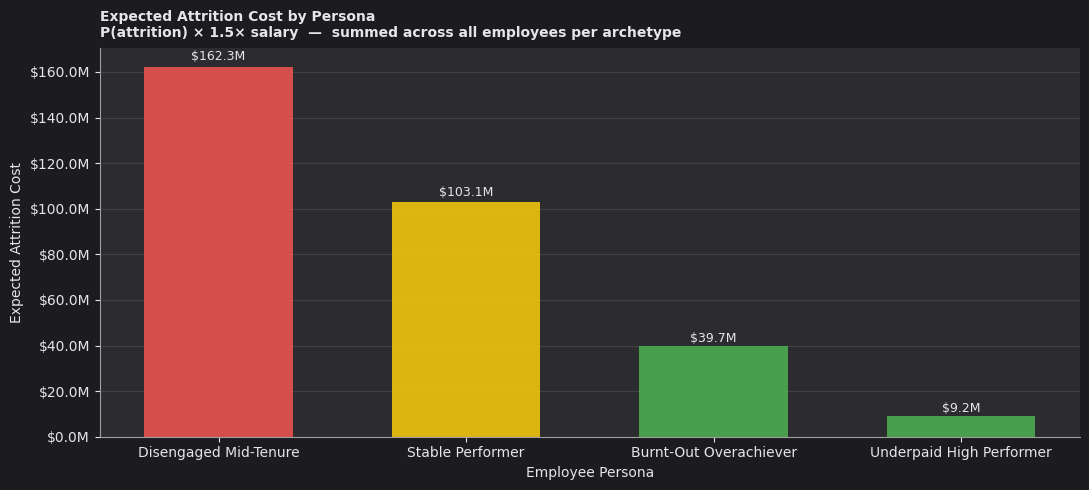

  Saved → outputs/retention_cost_by_persona.png

────────────────────────────────────────────────────────────
  17.3  Top-10 Highest Expected Cost Employees
────────────────────────────────────────────────────────────


,employee_idx,attrition_probability,risk_tier,cluster_persona,base_salary,expected_attrition_cost
1,4466,0.936,High,Burnt-Out Overachiever,"$165,050","$231,840"
2,8812,0.925,High,Disengaged Mid-Tenure,"$158,061","$219,424"
3,3087,0.827,High,Disengaged Mid-Tenure,"$166,399","$206,301"
4,9370,0.859,High,Disengaged Mid-Tenure,"$153,269","$197,586"
5,6450,0.834,High,Disengaged Mid-Tenure,"$155,430","$194,559"
6,9013,0.849,High,Disengaged Mid-Tenure,"$152,654","$194,385"
7,2075,0.719,High,Disengaged Mid-Tenure,"$177,332","$191,169"
8,7381,0.779,High,Disengaged Mid-Tenure,"$163,019","$190,460"
9,6963,0.859,High,Burnt-Out Overachiever,"$147,375","$189,876"
10,7653,0.679,High,Disengaged Mid-Tenure,"$185,868","$189,297"



────────────────────────────────────────────────────────────
  17.4  Artifact Persistence
────────────────────────────────────────────────────────────
  Saved risk_scored_employees.csv   → outputs/risk_scored_employees.csv  (10,000 rows)
  Saved retention_strategy_matrix.csv → outputs/retention_strategy_matrix.csv  (4 personas)

  Pipeline complete — all §16 and §17 artifacts written.


In [33]:
print_section("§17  Retention Strategy Recommendations")

# ═══════════════════════════════════════════════════════════════════════════════
# 17.1  Persona-Level Intervention Matrix
# ═══════════════════════════════════════════════════════════════════════════════

INTERVENTIONS: Dict[str, Tuple[str, str]] = {
    "Underpaid High Performer": (
        "Compensation gap",
        "Compensation review + market-rate salary adjustment + retention bonus",
    ),
    "Disengaged Mid-Tenure": (
        "Engagement & growth deficit",
        "Career pathing conversation + manager coaching + stretch assignments",
    ),
    "Burnt-Out Overachiever": (
        "Workload & burnout pressure",
        "Wellness programme + workload rebalance + flexible working pilot",
    ),
    "Stable Performer": (
        "Preventive retention",
        "Recognition programme + growth check-ins + peer mentoring",
    ),
}

retention_rows = []
for _, row in persona_table.iterrows():
    persona   = row["cluster_persona"]
    driver, action = INTERVENTIONS.get(persona, ("General risk", "Targeted manager intervention"))
    avg_prob  = row["avg_attrition_prob"]
    pct_high  = row["pct_high_risk"]
    headcount = row["headcount"]

    priority = "High"   if avg_prob >= 0.65 else ("Medium" if avg_prob >= 0.35 else "Low")
    est_roi  = "High"   if priority == "High" else ("Moderate" if priority == "Medium" else "Baseline")

    retention_rows.append({
        "Persona"               : persona,
        "Headcount"             : int(headcount),
        "Avg Attrition Prob"    : round(float(avg_prob), 3),
        "% High Risk"           : f"{pct_high:.1%}",
        "Primary Driver"        : driver,
        "Recommended Action"    : action,
        "Priority"              : priority,
        "Est. ROI Impact"       : est_roi,
    })

retention_strategy_matrix = (
    pd.DataFrame(retention_rows)
    .drop_duplicates(subset=["Persona"])
    .sort_values("Avg Attrition Prob", ascending=False)
    .reset_index(drop=True)
)

print_section("17.1  Intervention Matrix")
display(
    retention_strategy_matrix.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .map(
        lambda v: "color: #EF5350; font-weight:600"  if v == "High"
             else "color: #F6C90E;" if v == "Medium"
             else "color: #4CAF50;" if v == "Low"
             else "",
        subset=["Priority"],
    )
    .set_caption("Retention intervention matrix — one row per persona, sorted by average attrition probability")
)

# ═══════════════════════════════════════════════════════════════════════════════
# 17.2  Expected Attrition Cost per Employee
# ═══════════════════════════════════════════════════════════════════════════════
REPLACEMENT_MULTIPLIER = 1.5   # industry-standard: 1.5× annual salary

if "Base_Salary" in model_df.columns:
    base_salaries = model_df["Base_Salary"].values
    salary_source = "Base_Salary from model_df"
else:
    base_salaries = np.full(len(scored_df), 100_000.0)
    salary_source = "default $100,000 (Base_Salary column not found)"

scored_enriched = scored_df.copy()
scored_enriched["base_salary"]             = base_salaries
scored_enriched["replacement_cost"]        = REPLACEMENT_MULTIPLIER * scored_enriched["base_salary"]
scored_enriched["expected_attrition_cost"] = (
    scored_enriched["attrition_probability"] * scored_enriched["replacement_cost"]
)

print(f"\n  Salary source          : {salary_source}")
print(f"  Replacement multiplier : {REPLACEMENT_MULTIPLIER}×")
total_expected_cost = scored_enriched["expected_attrition_cost"].sum()
top20_mask          = scored_enriched["expected_attrition_cost"] >= scored_enriched["expected_attrition_cost"].quantile(0.80)
top20_cost          = scored_enriched.loc[top20_mask, "expected_attrition_cost"].sum()
potential_savings   = top20_cost * 0.30   # conservative 30% retention success rate

print(f"\n  Total expected attrition cost (full workforce) : ${total_expected_cost:>12,.0f}")
print(f"  Top-20% risk pool cost                         : ${top20_cost:>12,.0f}")
print(f"  Potential savings at 30% retention success     : ${potential_savings:>12,.0f}")

# ── Cost breakdown bar chart by persona ───────────────────────────────────────
cost_by_persona = (
    scored_enriched.groupby("cluster_persona")["expected_attrition_cost"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
ax.set_facecolor(CARD_BG)
ax.tick_params(colors=TEXT)

bar_colors_p = [LEAVE_COLOR if cost_by_persona.max() * 0.8 <= v else
                ACCENT       if cost_by_persona.max() * 0.4 <= v else
                STAY_COLOR   for v in cost_by_persona.values]
bars = ax.bar(cost_by_persona.index, cost_by_persona.values,
              color=bar_colors_p, alpha=0.88, width=0.6)

for bar, val in zip(bars, cost_by_persona.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"${val/1e6:.1f}M", ha="center", va="bottom", color=TEXT, fontsize=9)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.set_ylabel("Expected Attrition Cost", color=TEXT)
ax.set_xlabel("Employee Persona", color=TEXT)
ax.xaxis.grid(False)
ax.yaxis.grid(True, alpha=0.20)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
styled_title(ax, "Expected Attrition Cost by Persona",
             "P(attrition) × 1.5× salary  —  summed across all employees per archetype")
plt.tight_layout()
save_fig(fig, "retention_cost_by_persona")

# ═══════════════════════════════════════════════════════════════════════════════
# 17.3  Top-10 Priority Employees
# ═══════════════════════════════════════════════════════════════════════════════
top10 = (
    scored_enriched
    .sort_values("expected_attrition_cost", ascending=False)
    .head(10)
    [[
        "employee_idx",
        "attrition_probability",
        "risk_tier",
        "cluster_persona",
        "base_salary",
        "expected_attrition_cost",
    ]]
    .reset_index(drop=True)
)
top10.index = top10.index + 1   # 1-based rank

print_section("17.3  Top-10 Highest Expected Cost Employees")
display(
    top10.style
    .format({
        "attrition_probability" : "{:.3f}",
        "base_salary"           : "${:,.0f}",
        "expected_attrition_cost": "${:,.0f}",
    })
    .background_gradient(subset=["expected_attrition_cost"], cmap="Reds")
    .set_caption("Ranked by expected attrition cost — P(attrition) × 1.5× annual salary")
)

# ═══════════════════════════════════════════════════════════════════════════════
# 17.4  Save Output Artifacts
# ═══════════════════════════════════════════════════════════════════════════════
print_section("17.4  Artifact Persistence")

scored_export_path  = OUTPUT_DIR / "risk_scored_employees.csv"
strategy_path       = OUTPUT_DIR / "retention_strategy_matrix.csv"

scored_enriched[[
    "employee_idx",
    "attrition_probability",
    "risk_tier",
    "cluster",
    "cluster_persona",
    "base_salary",
    "expected_attrition_cost",
]].to_csv(scored_export_path, index=False)
print(f"  Saved risk_scored_employees.csv   → {scored_export_path}  ({len(scored_enriched):,} rows)")

retention_strategy_matrix.to_csv(strategy_path, index=False)
print(f"  Saved retention_strategy_matrix.csv → {strategy_path}  ({len(retention_strategy_matrix)} personas)")

print("\n  Pipeline complete — all §16 and §17 artifacts written.")
